# Phase 2 (projections) — grid extension vs. standalone solar

For every rural community of the Norte Amazónico study region we compare two ways to bring
electricity: extending the medium-voltage (MV) grid, or installing a standalone PV + battery
home system (SHS). The cheaper option on an annualised basis wins.

The **published classification is a greedy grid extension with definitive rejection and mid-span
taps**: starting from the existing MV network, the cheapest remaining candidate is connected as
long as the line still beats the standalone system; a rejected candidate is set aside for good
and the loop continues with the next one. A community therefore pays only the edge that links it
to its parent, not a private spur all the way back to the grid — neighbours share a trunk, and a
late community may tap into the middle of a line already built rather than run all the way to
its nearest endpoint. A tap creates a junction node, which is a point on a line and not a
community: it carries no household, no connection and no transformer.

The **node-only greedy**, the classification published before taps were allowed, is kept under
the `_glouton_noeud_seul` suffix.

The older **independent breakeven** screening (each community judged on its own spur from the
existing network) is kept alongside, under the `_breakeven_independant` suffix, because the
published CSVs carry both.

Layout: constants → data → core functions → horizons (2024 / 2035 / 2050) and CSV writing →
sensitivities → figures → final control.

> **Standalone ≠ no access.** A community classified `dispersed` is served by its own PV +
> battery system. It is not a community left without electricity.

## 1. Constants and sources

Every constant below carries its value, its source, and where that source lives in the
repository. Grid costs all come from the same table: Peña Balderrama et al. 2020,
*Energy for Sustainable Development* **56**, Table A.5 p.113.

In [49]:
import os

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shapely as shp
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import minimum_spanning_tree

pd.set_option("display.width", 250)

BASE = os.path.dirname(os.getcwd())   # repo root; this notebook lives in analyse_GIS_phase2_projections/
OUT = "output"
FIG_DIR = os.path.join(OUT, "figures")

# Cluster -> municipality membership. Same mapping as "analyse data ramp/sufficiency/demande.ipynb";
# these five clusters are the EnergyScope modelling zones of the region.
CLUSTERS = {
    "C1": ["Exaltación", "Reyes", "Santa_Rosa_Beni", "Ixiamas"],
    "C2": ["Bolpebra"],
    "C3": ["Guayaramerín", "Riberalta", "Puerto_Gonzalo_Moreno"],
    "C4": ["Bella_Flor", "Filadelfia", "Ingavi", "Nueva_Esperanza",
           "Porvenir", "Puerto_Rico", "San_Lorenzo", "San_Pedro",
           "Santa_Rosa_Pando", "Santos_Mercado", "Sena", "Villa_Nueva"],
    "C5": ["Cobija"],
}
MUNI_TO_CLUSTER = {m: c for c, munis in CLUSTERS.items() for m in munis}

EXT_YEARS = ["2024", "2035", "2050"]
ROOT = -1            # virtual root node of every extension tree = the existing MV network
UTM_CRS = "EPSG:32719"   # UTM zone 19S, metres — gis_phase2_analysis.ipynb cell 2 line 40

print(f"repo root      : {BASE}")
print(f"clusters       : {', '.join(f'{c} ({len(m)} mun.)' for c, m in CLUSTERS.items())}")
print(f"municipalities : {len(MUNI_TO_CLUSTER)}")

repo root      : c:\Valen\Tfe\bolivia-energy-data
clusters       : C1 (4 mun.), C2 (1 mun.), C3 (3 mun.), C4 (12 mun.), C5 (1 mun.)
municipalities : 21


In [50]:
FX = 0.924        # 1 USD -> EUR, 2024 annual average (IRS/ECB)
I_RATE = 0.10     # discount rate — Misc_indep.json

# --- Grid extension. All three from Peña Balderrama et al. 2020, ESD 56, Table A.5 p.113.
MV_USD = 9_000     # USD/km, 33 kV MV line
CONN_USD = 150     # USD/household, last-mile connection
TRAFO_USD = 3_500  # USD/community, MV/LV transformer station
LIFE_MV = 30       # years
OM_RATE = 0.02     # per year, O&M as a fraction of overnight capex — Tables A.5/A.7

MV_EUR = MV_USD * FX        # 8 316.0 EUR/km
CONN_EUR = CONN_USD * FX    # 138.6 EUR/household
TRAFO_EUR = TRAFO_USD * FX  # 3 234.0 EUR/community

# --- Standalone PV + battery. EnergyScope catalogue, cross-checked against 2024 retail
# prices (World Bank IDTR). These replace the Peña Balderrama Table A.7 USD figures.
PV_EUR_KW = 2_730    # EUR/kW — reg_technologies.dat:10
LIFE_PV = 20         # years — reg_technologies.dat:10
BAT_EUR_KWH = 594    # EUR/kWh — reg_technologies.dat:138
LIFE_BAT = 10        # years

# --- SHS sizing, standard tropical off-grid design. The three sources below are OUTSIDE this
# repository (bibliographic references, not files the control cell can read back), which is why
# they are spelled out in full here and marked SOURCE HORS DEPOT.
SYS_EFF = 0.75    # PV -> usable AC, incl. battery/inverter/wiring losses.
                  # SOURCE HORS DEPOT: Panjon 2010, Revista Tecnica "energia" 6(1), p.91 --
                  # "rendimiento global" of a standalone installation feeding AC loads.
BATT_DAYS = 2     # days of autonomy.
                  # SOURCE HORS DEPOT: Lighting Global / World Bank, "Requirements and
                  # Guidelines for Installation of Off-Grid Solar Systems for Public
                  # Facilities", 2021 rev. 2023, p.25 section 5.2.7 -- 3 to 5 days typical,
                  # 1.5 to 2 days for non-critical loads. Rural household lighting and phone
                  # charging is a non-critical load, so the central value sits at the TOP of
                  # the non-critical band. Sensitivity (c) spans 1 day and 3 days, 3 being the
                  # bottom of the "typical" band -- the two bands are therefore both covered.
BATT_DOD = 0.80   # depth of discharge.
                  # SOURCE HORS DEPOT: Lighting Global / World Bank, same document, p.28
                  # section 5.2.9 -- 70 to 90 % typical for lithium. 0.80 is mid-band.

# --- Existing home-system unit sizes, for the brownfield f_min fed to EnergyScope.
# Source: ENDE BO-L1222 / Programa de Electrificación Rural, aligned with home_systems.ipynb.
PANEL_W = 50                   # Wp per panel-household (ENDE PEVD kit: >= 50 Wp)
GEN_W = 500                    # W per generator-household
BATT_KWH_PER_PANEL_HH = 0.123  # kWh per panel-household (ENDE PEVD kit: 123 Wh lithium 12 V)


def crf(rate, life):
    """Capital recovery factor: annualises an overnight cost over `life` years at `rate`."""
    return rate * (1 + rate) ** life / ((1 + rate) ** life - 1)


CRF_MV = crf(I_RATE, LIFE_MV)
CRF_PV = crf(I_RATE, LIFE_PV)
CRF_BAT = crf(I_RATE, LIFE_BAT)

assert abs(CRF_MV - 0.10607925) < 1e-8, f"unexpected CRF_MV: {CRF_MV}"

pd.DataFrame([
    {"parameter": "FX (USD->EUR)", "value": FX, "source": "2024 annual average, IRS/ECB"},
    {"parameter": "discount rate", "value": I_RATE, "source": "Misc_indep.json"},
    {"parameter": "MV line", "value": f"{MV_USD} USD/km -> {MV_EUR:,.1f} EUR/km", "source": "Peña Balderrama 2020, Table A.5 p.113"},
    {"parameter": "connection", "value": f"{CONN_USD} USD/HH -> {CONN_EUR:.1f} EUR/HH", "source": "Peña Balderrama 2020, Table A.5 p.113"},
    {"parameter": "transformer", "value": f"{TRAFO_USD} USD -> {TRAFO_EUR:,.1f} EUR/community", "source": "Peña Balderrama 2020, Table A.5 p.113"},
    {"parameter": "O&M rate", "value": OM_RATE, "source": "Peña Balderrama 2020, Tables A.5/A.7"},
    {"parameter": "PV capex", "value": f"{PV_EUR_KW} EUR/kW", "source": "reg_technologies.dat:10, x-checked IDTR World Bank"},
    {"parameter": "battery capex", "value": f"{BAT_EUR_KWH} EUR/kWh", "source": "reg_technologies.dat:138"},
    {"parameter": "system efficiency", "value": SYS_EFF, "source": "HORS DEPOT - Panjon 2010, Revista Tecnica energia 6(1) p.91"},
    {"parameter": "days of autonomy", "value": BATT_DAYS, "source": "HORS DEPOT - Lighting Global/World Bank 2021 rev.2023 p.25 s.5.2.7 (3-5 typical, 1.5-2 non-critical)"},
    {"parameter": "depth of discharge", "value": BATT_DOD, "source": "HORS DEPOT - Lighting Global/World Bank 2021 rev.2023 p.28 s.5.2.9 (70-90 % lithium)"},
    {"parameter": "lifetimes MV/PV/battery", "value": f"{LIFE_MV}/{LIFE_PV}/{LIFE_BAT} y", "source": "Table A.5 (MV) / reg_technologies.dat"},
    {"parameter": "CRF MV/PV/battery", "value": f"{CRF_MV:.6f}/{CRF_PV:.6f}/{CRF_BAT:.6f}", "source": f"crf(i={I_RATE}, n)"},
])

,parameter,value,source
0,FX (USD->EUR),0.924,"2024 annual average, IRS/ECB"
1,discount rate,0.1,Misc_indep.json
2,MV line,"9000 USD/km -> 8,316.0 EUR/km","Peña Balderrama 2020, Table A.5 p.113"
3,connection,150 USD/HH -> 138.6 EUR/HH,"Peña Balderrama 2020, Table A.5 p.113"
4,transformer,"3500 USD -> 3,234.0 EUR/community","Peña Balderrama 2020, Table A.5 p.113"
5,O&M rate,0.02,"Peña Balderrama 2020, Tables A.5/A.7"
6,PV capex,2730 EUR/kW,"reg_technologies.dat:10, x-checked IDTR World ..."
7,battery capex,594 EUR/kWh,reg_technologies.dat:138
8,system efficiency,0.75,"HORS DEPOT - Panjon 2010, Revista Tecnica ener..."
9,days of autonomy,2,HORS DEPOT - Lighting Global/World Bank 2021 r...


## 2. Data

Five inputs, plus the geometry needed by the tree and the maps:

| input | file |
|---|---|
| households and off-grid counts, Census 2024 | `exctraction of data/output/CSV_final.csv` |
| per-household demand profiles | `analyse data ramp/sufficiency/data ramp/<muni>/load_curve_*.csv` |
| solar capacity factor per cluster | `analyse data ramp/sufficiency/output_energyscope/<cluster>/Time_series.csv` |
| community distances to the MV network | `analyse_GIS_phase2/output/task1_community_distances_lines.csv` |
| community electrification, Census 2012 | `analyse_GIS_phase2/data/comunidades_electricidad_2012.csv` |
| community geometry | `data/comunidades_electricidad_2012.json` |
| MV network 2023 | `data/Líneas_de_Media_Tensión_2023.json` |
| projected households | `projections/output/menages_projetes.csv` |

`distance_km` is **taken as given** from `task1_community_distances_lines.csv`, never recomputed.
The geometry is joined only to obtain metric coordinates; the assertion at the end of this
section checks that the perpendicular foot recovers `distance_km` to 1e-12 km, which is what
makes community–community edges and community–grid edges commensurable.

In [51]:
# --- Households and per-household electricity demand -------------------------------------
csv_final = pd.read_csv(os.path.join(BASE, "exctraction of data/output/CSV_final.csv"),
                        encoding="utf-8-sig")
hh_col = [c for c in csv_final.columns
          if "2024" in c and "Total" in c and "VIVIENDA" in c.upper()][0]


def std_muni_name(depto, raw):
    """Map CSV_final municipality names onto the CLUSTERS keys.
    'Santa Rosa' exists in both Beni and Pando — disambiguate by department."""
    raw = str(raw).strip()
    if raw == "Santa Rosa":
        return "Santa_Rosa_Beni" if depto == "Beni" else "Santa_Rosa_Pando"
    return raw.replace(" ", "_")


muni_rows = csv_final[csv_final["MUNICIPIO/TIOC"].notna()]
total_hh = {
    std_muni_name(row["DEPARTAMENTO"], row["MUNICIPIO/TIOC"]): row[hh_col]
    for _, row in muni_rows.iterrows()
    if std_muni_name(row["DEPARTAMENTO"], row["MUNICIPIO/TIOC"]) in MUNI_TO_CLUSTER
}
assert set(total_hh) == set(MUNI_TO_CLUSTER), "missing total_hh for some municipalities"

# APPOINT_ELEC_SHARE: region-wide share of decentralised hot water met by the electric
# resistance host tech (DEC_DIRECT_ELEC) in the "appoint réaliste" sufficiency variant of
# EnergyScope_BO_nord_amazonia — 3.9468 / 71.6685 GWh from the sufficiency_phase2 run.
# sufficiency_water_heating is excluded from the SHS sizing on purpose: off-grid households do
# not run electric water heating, so including it would oversize PV+battery and understate the
# standalone cost. Only this small electric fraction is added back.
APPOINT_ELEC_SHARE = 0.04825
ECS_APPOINT_KWH_HH = 851 * APPOINT_ELEC_SHARE

RAMP_DIR = os.path.join(BASE, "analyse data ramp/sufficiency/data ramp")
per_hh_kwh, no_ramp_file = {}, []
for muni in MUNI_TO_CLUSTER:
    path = os.path.join(RAMP_DIR, muni, "load_curve_energy_service_full_year_Norte_Amazonia.csv")
    if not os.path.exists(path):
        no_ramp_file.append(muni)
        continue
    df = pd.read_csv(path)
    suff_cols = [c for c in df.columns
                 if c.startswith("sufficiency_") and c != "sufficiency_water_heating"]
    per_hh_kwh[muni] = df[suff_cols].sum().sum() / 60_000.0 / total_hh[muni] + ECS_APPOINT_KWH_HH

# A few municipalities have no RAMP run -> total_hh-weighted average of their cluster peers.
for muni in no_ramp_file:
    peers = [p for p in CLUSTERS[MUNI_TO_CLUSTER[muni]] if p in per_hh_kwh]
    per_hh_kwh[muni] = (sum(per_hh_kwh[p] * total_hh[p] for p in peers)
                        / sum(total_hh[p] for p in peers))
    print(f"{muni}: no RAMP file -> cluster average over {peers}")

# The sufficiency scenario is uniform by design, so every municipality must land close to the
# same per-household value. A drift here would mean a broken RAMP run upstream.
_mean_kwh = np.mean(list(per_hh_kwh.values()))
_dev = max(abs(v / _mean_kwh - 1) for v in per_hh_kwh.values())
assert _dev < 0.05, f"per_hh_kWh spread {_dev:.1%} > 5% — sufficiency scenario is not uniform"
print(f"per_hh_kWh = {_mean_kwh:,.1f} mean, max deviation {_dev:.2%} (uniform by design) -> OK")

per_hh_kWh = 1,168.9 mean, max deviation 3.21% (uniform by design) -> OK


In [52]:
# --- Standalone system size and cost, per municipality ------------------------------------
cf_pv = {}
for cluster in CLUSTERS:
    ts = pd.read_csv(os.path.join(
        BASE, f"analyse data ramp/sufficiency/output_energyscope/{cluster}/Time_series.csv"),
        sep=";", index_col=0)
    cf_pv[cluster] = ts["PV"].mean()


def size_shs(kwh_per_year, cf, sys_eff=SYS_EFF, batt_days=BATT_DAYS, batt_dod=BATT_DOD,
             crf_bat=CRF_BAT):
    """Standalone PV + battery for one household: (overnight capex, annualised cost) in EUR.

    No solar-thermal water heater capex enters here: that equipment is needed on BOTH sides of
    the comparison (grid-connected and standalone alike), so it cancels out.

    The four sizing arguments default to the published values; sensitivity (c) overrides them
    one at a time. Nothing else in the notebook passes them.
    """
    pv_kw = kwh_per_year / (cf * 8760 * sys_eff)
    bat_kwh = (batt_days * kwh_per_year / 365) / batt_dod
    pv_eur = pv_kw * PV_EUR_KW
    bat_eur = bat_kwh * BAT_EUR_KWH
    capex = pv_eur + bat_eur
    return capex, CRF_PV * pv_eur + crf_bat * bat_eur + OM_RATE * capex


shs_capex, shs_annual = {}, {}
for muni, kwh in per_hh_kwh.items():
    shs_capex[muni], shs_annual[muni] = size_shs(kwh, cf_pv[MUNI_TO_CLUSTER[muni]])

pd.DataFrame([{"cluster": MUNI_TO_CLUSTER[m], "municipio": m,
               "per_hh_kWh": round(per_hh_kwh[m], 1),
               "overnight_capex_EUR_HH": round(shs_capex[m], 0),
               "annual_EUR_HH": round(shs_annual[m], 2)}
              for m in MUNI_TO_CLUSTER]).sort_values(["cluster", "municipio"])

,cluster,municipio,per_hh_kWh,overnight_capex_EUR_HH,annual_EUR_HH
0,C1,Exaltación,1173.8,7580.0,1258.21
3,C1,Ixiamas,1131.4,7306.0,1212.80
1,C1,Reyes,1158.1,7479.0,1241.38
2,C1,Santa_Rosa_Beni,1176.3,7596.0,1260.89
4,C2,Bolpebra,1166.8,7582.0,1257.14
5,C3,Guayaramerín,1175.3,7576.0,1257.87
7,C3,Puerto_Gonzalo_Moreno,1173.4,7563.0,1255.82
6,C3,Riberalta,1174.9,7573.0,1257.49
8,C4,Bella_Flor,1169.4,7712.0,1275.52
9,C4,Filadelfia,1164.3,7678.0,1269.91


In [53]:
# --- Communities: Source C (unelectrified) + Source B (already off-grid electrified) -------
# The household count that enters the breakeven is C + B. Source B households live in the SAME
# communities and share the same line, so a community with enough of them can be worth
# connecting even when Source C alone would not justify it.
task1 = pd.read_csv(os.path.join(
    BASE, "analyse_GIS_phase2/output/task1_community_distances_lines.csv"), encoding="utf-8-sig")

# 2024 municipal Source B totals (Motor / Panel / Otra) from the census
motor_col = [c for c in csv_final.columns if "2024" in c and "Motor" in c and "VIVIENDA" in c.upper()][0]
panel_col = [c for c in csv_final.columns if "2024" in c and "Panel" in c][0]
otra_col = [c for c in csv_final.columns if "2024" in c and "Otra" in c][0]
muni_b = {std_muni_name(r["DEPARTAMENTO"], r["MUNICIPIO/TIOC"]):
          {"total": r[motor_col] + r[panel_col] + r[otra_col], "motor": r[motor_col],
           "panel": r[panel_col], "otra": r[otra_col]}
          for _, r in csv_final[csv_final["MUNICIPIO/TIOC"].notna()].iterrows()
          if std_muni_name(r["DEPARTAMENTO"], r["MUNICIPIO/TIOC"]) in MUNI_TO_CLUSTER}

# 2012 community-level electrification survey, normalised onto the MUNI_TO_CLUSTER keys.
com2012 = pd.read_csv(os.path.join(
    BASE, "analyse_GIS_phase2/data/comunidades_electricidad_2012.csv"),
    encoding="utf-8-sig", low_memory=False)
com2012["Municipio_std"] = (com2012["Municipio"].str.extract(r"- (.+)$")[0].str.strip()
                            .fillna(com2012["Municipio"].str.strip()))
# "Santa Rosa" exists in Beni and in Pando; Pando's is recorded as "Santa Rosa del Abuná".
# Disambiguate by department BEFORE the general space -> underscore normalisation.
_sr = com2012["Municipio_std"].str.contains("Santa Rosa", na=False)
com2012.loc[_sr & (com2012["Depto"] == "Beni"), "Municipio_std"] = "Santa_Rosa_Beni"
com2012.loc[_sr & (com2012["Depto"] == "Pando"), "Municipio_std"] = "Santa_Rosa_Pando"
# "Villa Nueva (Loma Alta)" carries a parenthetical the general rule would not strip.
com2012.loc[com2012["Municipio_std"].str.contains("Villa Nueva", na=False), "Municipio_std"] = "Villa_Nueva"
com2012["Municipio_std"] = com2012["Municipio_std"].str.replace(" ", "_", regex=False)
assert not set(MUNI_TO_CLUSTER) - set(com2012["Municipio_std"]), \
    "a MUNI_TO_CLUSTER municipality has no matching 2012 row — Source B would silently be 0"

# B_2012 = min(Motor+Panel+Otra, Hog_Elec - Red_elec), capped to avoid double-counting the
# households the survey already reports as grid-connected, then scaled to the 2024 municipal total.
study_b = com2012[com2012["Municipio_std"].isin(MUNI_TO_CLUSTER)].copy()
study_b["B_2012_raw"] = (study_b["Motor"].fillna(0) + study_b["Panel"].fillna(0)
                         + study_b["Otra"].fillna(0))
study_b["B_cap"] = (study_b["Hog_Elec"].fillna(0) - study_b["Red_elec"].fillna(0)).clip(lower=0)
study_b["B_2012"] = study_b[["B_2012_raw", "B_cap"]].min(axis=1)
for _c in ("Panel", "Motor", "Otra"):
    study_b[f"{_c}_2012"] = study_b[_c].fillna(0)
study_b["Comunidad_norm"] = study_b["Comunidad"].str.strip().str.upper()

for _col12, _key in [("B_2012", "total"), ("Panel_2012", "panel"),
                     ("Motor_2012", "motor"), ("Otra_2012", "otra")]:
    _denom = study_b.groupby("Municipio_std")[_col12].transform("sum")
    _b24 = study_b["Municipio_std"].map({m: muni_b[m][_key] for m in muni_b})
    study_b[_col12.replace("_2012", "_2024")] = (
        study_b[_col12] / _denom.replace(0, float("nan")) * _b24).fillna(0)

BCOLS = ["B_2024", "Panel_2024", "Motor_2024", "Otra_2024"]
b_comm = (study_b.groupby(["Municipio_std", "Comunidad_norm"])[BCOLS].sum().reset_index())

# Assign onto task1 by (Municipio_std, Comunidad_norm) WITHOUT merging, to preserve the exact
# 697-row structure. Where several distinct communities share a name inside one municipality,
# the community-level value is SPLIT across them (weighted by Poblacion_2012), not duplicated.
task1_bc = task1.copy()
task1_bc["Comunidad_norm"] = task1_bc["Comunidad"].str.strip().str.upper()
GROUP_KEYS = ["Municipio_std", "Comunidad_norm"]
_group_pop = task1_bc.groupby(GROUP_KEYS)["Poblacion_2012"].transform("sum")
_n_in_group = task1_bc.groupby(GROUP_KEYS)["Comunidad_norm"].transform("size")
_share = (task1_bc["Poblacion_2012"] / _group_pop).where(_group_pop > 0, 1.0 / _n_in_group)
_b_per_key = (b_comm.set_index(GROUP_KEYS)[BCOLS]
              .reindex(pd.MultiIndex.from_frame(task1_bc[GROUP_KEYS])).fillna(0.0))
for _col in BCOLS:
    task1_bc[_col] = _b_per_key[_col].values * _share.values

# Every census household must be either assigned or covered by the known residual: some 2012
# community names have no counterpart at all in the GIS layer (pre-existing data-quality gap
# between two independently compiled lists).
_assigned = task1_bc["B_2024"].sum()
_orphans = set(zip(b_comm["Municipio_std"], b_comm["Comunidad_norm"])) \
    - set(zip(task1_bc["Municipio_std"], task1_bc["Comunidad_norm"]))
_orphan_hh = (b_comm.set_index(GROUP_KEYS).loc[list(_orphans), "B_2024"].sum() if _orphans else 0.0)
_census_b = sum(muni_b[m]["total"] for m in muni_b)
assert abs((_assigned + _orphan_hh) - _census_b) < 1.0, \
    f"unexplained Source B gap: {_assigned:.1f} + {_orphan_hh:.1f} != {_census_b:.0f}"
print(f"Source B: {_assigned:,.1f} households assigned + {_orphan_hh:,.1f} unmatched "
      f"({len(_orphans)} community names absent from the GIS layer) = census {_census_b:,.0f} -> OK")

task1_bc["HH_2024_scaled"] = task1_bc["HH_2024_scaled"] + task1_bc["B_2024"]
print(f"{len(task1_bc)} communities, {task1_bc['HH_2024_scaled'].sum():,.0f} households (C + B)")

Source B: 9,078.1 households assigned + 246.9 unmatched (30 community names absent from the GIS layer) = census 9,325 -> OK
697 communities, 20,467 households (C + B)


In [54]:
# --- Geometry, MV network layer, and the distance_km reproduction check --------------------
# task1_community_distances_lines.csv carries no coordinates; the geometry only exists in the
# GeoJSON. MUNI_FILTER below is copied verbatim from gis_phase2_analysis.ipynb cell 5 — it is
# what defines the 697 communities. The No_tiene > 0 filter is its cell 6.
MUNI_FILTER = [
    ("Exaltación", "Beni", "Exaltac"), ("Guayaramerín", "Beni", "Guayaramer"),
    ("Reyes", "Beni", "Reyes"), ("Riberalta", "Beni", "Riberalta"),
    ("Santa_Rosa_Beni", "Beni", "Santa Rosa"), ("Ixiamas", "La Paz", "Ixiamas"),
    ("Bella_Flor", "Pando", "Bella Flor"), ("Bolpebra", "Pando", "Bolpebra"),
    ("Cobija", "Pando", "Cobija"), ("Filadelfia", "Pando", "Filadelfia"),
    ("Ingavi", "Pando", "Ingavi"), ("Nueva_Esperanza", "Pando", "Nueva Esperanza"),
    ("Porvenir", "Pando", "Porvenir"), ("Puerto_Gonzalo_Moreno", "Pando", "Puerto Gonzalo"),
    ("Puerto_Rico", "Pando", "Puerto Rico"), ("San_Lorenzo", "Pando", "San Lorenzo"),
    ("San_Pedro", "Pando", "San Pedro"), ("Santa_Rosa_Pando", "Pando", "Santa Rosa del Abun"),
    ("Santos_Mercado", "Pando", "Santos Mercado"), ("Sena", "Pando", "Sena"),
    ("Villa_Nueva", "Pando", "Villa Nueva"),
]

_com = gpd.read_file("data/comunidades_electricidad_2012.json")
_com.set_crs("EPSG:4326", inplace=True, allow_override=True)
_parts = []
for _std, _dept, _sub in MUNI_FILTER:
    _s = _com[_com["Depto"].str.contains(_dept, case=False, na=False)
              & _com["Municipio"].str.contains(_sub, case=False, na=False)].copy()
    _s["Municipio_std"] = _std
    _parts.append(_s)
_geo = pd.concat(_parts, ignore_index=True)
for _c in ("No_tiene", "poblacion"):
    _geo[_c] = pd.to_numeric(_geo[_c], errors="coerce").fillna(0)
_geo = (_geo[_geo["No_tiene"] > 0].to_crs(UTM_CRS)
        .rename(columns={"No_tiene": "No_tiene_2012", "poblacion": "Poblacion_2012"}))
_geo["x_utm_m"], _geo["y_utm_m"] = _geo.geometry.x, _geo.geometry.y

GEO_KEY = ["Municipio_std", "Comunidad", "No_tiene_2012", "Poblacion_2012"]
assert not _geo.duplicated(GEO_KEY).any(), "join key not unique on the GeoJSON side"
assert not task1_bc.duplicated(GEO_KEY).any(), "join key not unique on the task1 side"
task1_geo = task1_bc.merge(_geo[GEO_KEY + ["x_utm_m", "y_utm_m"]], on=GEO_KEY,
                           how="left", validate="one_to_one")
assert len(task1_geo) == 697, f"expected 697 communities, got {len(task1_geo)}"
assert task1_geo["x_utm_m"].notna().all(), "communities left without geometry after the join"

XY = task1_geo[["x_utm_m", "y_utm_m"]].to_numpy()
D_GRID = task1_geo["distance_km"].to_numpy()          # taken from task1, never recomputed
CL_ARR = task1_geo["Cluster"].to_numpy()
CL_MUNI = task1_geo["Municipio_std"].to_numpy()       # positional municipality lookup
# Planar euclidean community-community distances, same CRS and same metric as distance_km, so
# that community-community and community-grid edges are commensurable.
D_COMM = np.hypot(XY[:, 0, None] - XY[None, :, 0], XY[:, 1, None] - XY[None, :, 1]) / 1000.0

# MV network 2023: the map background, and the exact point where a spur reaches the grid.
_lin = gpd.read_file("data/Líneas_de_Media_Tensión_2023.json")
_lin.set_crs("EPSG:4326", inplace=True, allow_override=True)
LIN_UTM = _lin.to_crs(UTM_CRS)
FOOT = np.array([shp.get_coordinates(g)[1] for g in
                 shp.shortest_line([shp.Point(p) for p in XY], LIN_UTM.geometry.union_all())])

_err = np.abs(np.hypot(FOOT[:, 0] - XY[:, 0], FOOT[:, 1] - XY[:, 1]) / 1000.0 - D_GRID).max()
assert _err < 1e-12, f"perpendicular foot does not reproduce distance_km: max error {_err:.2e} km"
print(f"geometry joined to {len(task1_geo)} communities, CRS {UTM_CRS}")
print(f"MV network 2023: {len(LIN_UTM)} features")
print(f"distance_km reproduced from the geometry to {_err:.2e} km (< 1e-12) -> OK")

geometry joined to 697 communities, CRS EPSG:32719
MV network 2023: 653 features
distance_km reproduced from the geometry to 8.85e-13 km (< 1e-12) -> OK


In [55]:
# --- Projected household counts per cluster -----------------------------------------------
# Only the household count moves between horizons. Distances, per-household demand and every
# unit cost stay exactly as computed above.
proj = pd.read_csv(os.path.join(BASE, "projections/output/menages_projetes.csv"))
hh_by_cluster_year = proj.groupby("cluster")[["hh_2024", "hh_2035", "hh_2050"]].sum()
hh_2024_baseline = hh_by_cluster_year["hh_2024"]

# The 2024 column must match this notebook's own census totals, so the 2024 scale factors are
# exactly 1.0 and the 2024 run is a true control.
for _c in CLUSTERS:
    assert abs(hh_2024_baseline[_c] - sum(total_hh[m] for m in CLUSTERS[_c])) < 1e-6, \
        f"{_c}: hh_2024 in menages_projetes.csv != total_hh from CSV_final"

SCENARIOS = {"2024": hh_2024_baseline,
             "2035": hh_by_cluster_year["hh_2035"],
             "2050": hh_by_cluster_year["hh_2050"]}
pd.DataFrame({y: SCENARIOS[y].round(0) for y in EXT_YEARS})

,2024,2035,2050
cluster,,,
C1,10933.0,12942.0,14873.0
C2,802.0,998.0,1204.0
C3,40298.0,47958.0,55641.0
C4,16612.0,20801.0,25487.0
C5,15564.0,19084.0,22994.0


## 3. Core functions

**The breakeven test.** A community is `dispersed` (standalone wins) when its annualised
standalone cost is below the annualised cost of connecting it:

$$\text{extension}_{HH} = (CRF_{MV} + OM)\times\Big[MV_{EUR/km}\times\frac{d}{HH} + CONN_{EUR}\Big]$$

**The greedy extension.** `greedy_connect` grows the connected set from the existing MV network
outwards. At each step the cheapest remaining candidate is measured on its *attachment cost* —
the shorter of its own perpendicular to the grid and its distance to an already-connected
community of the **same cluster** — and accepted if it passes the same breakeven test. A
rejected candidate is blocked for good and the loop moves on. Inter-cluster edges are forbidden
throughout: C1–C5 are distinct EnergyScope modelling zones, a line joining two of them would
correspond to nothing in the model.

**Mid-span taps, and what is published.** `greedy_connect` can only attach a community to a
**node**: an already connected community, or the perpendicular foot on the existing network. It
cannot tap into an **interior point** of an edge it has already built, although a mid-span tap is
ordinary distribution practice. `greedy_connect_with_taps` lifts that single restriction and **is
the published classification**; `greedy_connect` is kept unmodified beside it and reported under
the `_glouton_noeud_seul` suffix. The attachment cost becomes

$$\text{attach}_i = \min\Big(D_{GRID}[i],\ \min_{e \in \text{tree},\ cl(e)=cl(i)}
\ d_{\text{point-segment}}(i, e)\Big)$$

Attaching to a node is the case $t = 0$ or $t = 1$ of that minimum, so it needs no separate
branch. When the minimum falls at an interior point of an edge $(a,b)$, a junction node `T` is
created at the projected point, $(a,b)$ is replaced by $(a,T) + (T,b)$ — total length unchanged —
and $(T,i)$ is added. **A junction is not a community**: it carries no transformer, no connection
and no household, so `N_connectable` keeps its definition and the transformer post stays
`N_connectable × TRAFO_EUR`, never the edge count. Its cluster is that of the edge it cuts,
unambiguous since inter-cluster edges stay forbidden.

The transformer post reaches the breakeven test through an exact length equivalence,
`TRAFO_EUR/HH == MV_EUR × (TRAFO_EUR/MV_EUR)/HH`, so the candidate is tested at
`attach_cost + TRAFO_EUR/MV_EUR` km. This is an identity, not an approximation.

**Capex.** Three posts: line (EUR/km on the tree length), transformer (EUR per connected
community), connection (EUR per connected household).

In [56]:
def annual_extension_cost(distance_km, hh, mv_eur):
    """Annualised grid-extension cost, EUR per household per year."""
    slope = (CRF_MV + OM_RATE) * mv_eur
    return slope * distance_km / hh + (CRF_MV + OM_RATE) * CONN_EUR


def classify_communities(communities, mv_eur=MV_EUR):
    """Independent breakeven: judge every community on its own spur from the existing network.

    Returns one row per community with HH > 0, in input order. `breakeven_distance_km` is the
    distance at which the two options cost the same; it scales with the household count.
    """
    rows = []
    for _, row in communities.iterrows():
        muni, dist, hh = row["Municipio_std"], row["distance_km"], row["HH_2024_scaled"]
        if hh <= 0:
            continue
        standalone = shs_annual[muni]
        extension = annual_extension_cost(dist, hh, mv_eur)
        slope = (CRF_MV + OM_RATE) * mv_eur
        d_star = max((standalone - (CRF_MV + OM_RATE) * CONN_EUR) * hh / slope, 0.0)
        rows.append({
            "Cluster": row["Cluster"], "Comunidad": row["Comunidad"], "Municipio_std": muni,
            "HH": hh, "distance_km": dist, "nearest_line_type": row["nearest_line_type"],
            "annual_extension_EUR_HH": round(extension, 2),
            "annual_standalone_EUR_HH": round(standalone, 2),
            "dispersed": standalone < extension,
            "breakeven_distance_km": round(d_star, 3),
        })
    return pd.DataFrame(rows)


def capex_posts(length_km, n_connectable, hh_connectable, mv_eur=None):
    """Extension capex split into its three posts. `mv_eur` lets the sensitivity vary the
    line cost without touching the published value."""
    mv = MV_EUR if mv_eur is None else mv_eur
    ligne = length_km * mv
    transfo = n_connectable * TRAFO_EUR
    raccord = hh_connectable * CONN_EUR
    total = ligne + transfo + raccord
    return {"ligne_EUR": ligne, "transformateur_EUR": transfo, "raccordement_EUR": raccord,
            "total_EUR": total,
            # Published convention: CRF only. This is what extension_capex_annualise_EUR carries.
            "total_annualise_EUR": CRF_MV * total,
            # The convention the CLASSIFICATION actually used: annual_extension_cost annualises at
            # CRF_MV + OM_RATE. Never written to a CSV; printed by the control cell so the gap
            # between the two conventions is quotable in the limitations.
            "total_annualise_avec_om_EUR": (CRF_MV + OM_RATE) * total}

In [57]:
def greedy_connect(hh, mv_eur=MV_EUR, shs_annual_by_muni=None):
    """Greedy grid extension with definitive rejection — the published classification.

    Repeatedly take the eligible candidate with the lowest per-household extension cost and
    apply the breakeven test at its current attachment cost. Accepted: it joins the tree, and
    its neighbours of the same cluster may now attach to it more cheaply. Rejected: it is
    blocked for good and the loop continues with the next candidate.

    Termination is guaranteed: every iteration moves exactly one community into either the
    connected set or the blocked set, and none ever comes back out.

    `shs_annual_by_muni` defaults to the published standalone costs; sensitivity (c) passes a
    re-sized variant.

    Returns (connected mask, {frozenset({i, parent}): edge length in km}, n_blocked_would_pass).
    """
    trafo_km_eq = TRAFO_EUR / mv_eur    # transformer post expressed as an equivalent length
    n = len(hh)
    connected = np.zeros(n, dtype=bool)
    blocked = hh <= 0                   # a community without households is never a candidate
    edges = {}
    attach_cost = D_GRID.astype(float).copy()   # start: everyone attaches straight to the grid
    attach_parent = np.full(n, ROOT, dtype=int)
    standalone = np.array([(shs_annual if shs_annual_by_muni is None else shs_annual_by_muni)[m]
                           for m in CL_MUNI])

    while True:
        elig = np.where((~connected) & (~blocked))[0]
        if len(elig) == 0:
            break
        ext = mv_eur * attach_cost[elig] / hh[elig] + CONN_EUR + TRAFO_EUR / hh[elig]
        c = int(elig[np.argmin(ext)])

        if standalone[c] < annual_extension_cost(attach_cost[c] + trafo_km_eq, hh[c], mv_eur):
            blocked[c] = True
            continue

        connected[c] = True
        edges[frozenset((c, int(attach_parent[c])))] = float(attach_cost[c])

        # Only same-cluster communities may attach to c: inter-cluster edges are forbidden.
        cand = np.where((~connected) & (CL_ARR == CL_ARR[c]))[0]
        if len(cand):
            better = D_COMM[cand, c] < attach_cost[cand]
            attach_cost[cand[better]] = D_COMM[cand[better], c]
            attach_parent[cand[better]] = c

    assert len(edges) == int(connected.sum()), "one parent edge per connected community"

    # What the definitive rejection costs. A blocked community keeps accumulating cheaper
    # attachment options after it is set aside, because attach_cost only ever decreases. At the
    # END of the loop each blocked community therefore sits at the lowest cost it will ever
    # reach; if one of them would now pass the test it failed, the rejection order threw away a
    # connection that the same criterion would have accepted, and the result would depend on the
    # order rather than on the economics. Blocking, not a diagnostic: it must be 0.
    _blocked_pass = [c for c in np.where(blocked & (hh > 0))[0]
                     if standalone[c] >= annual_extension_cost(attach_cost[c] + trafo_km_eq,
                                                               hh[c], mv_eur)]
    assert not _blocked_pass, (
        f"{len(_blocked_pass)} blocked communities would pass the test at their final "
        f"attach_cost: definitive rejection is not neutral here")
    return connected, edges, len(_blocked_pass)

In [58]:
# --- The published attachment rule: greedy extension with mid-span taps ---------------------
# greedy_connect above can only attach a community to a NODE — an already connected community,
# or the perpendicular foot on the existing MV network. It cannot tap into an INTERIOR point of
# an edge it has already built, although a mid-span tap is ordinary distribution practice. On the
# node-only 2024 tree, 43 of its 83 standalone communities had a tree edge passing closer than
# any attachable node, and 32 of them projected strictly inside a community-community edge.
# greedy_connect_with_taps below lifts that single restriction and IS THE PUBLISHED
# CLASSIFICATION. greedy_connect is kept above, unmodified, and reported alongside under the
# _glouton_noeud_seul suffix.

def _dist_point_to_segments(p, A, B):
    """Distance (km) and parameter t from the point `p` to each segment A[k]-B[k]. Metres in."""
    AB = B - A
    den = (AB ** 2).sum(1)
    den = np.where(den == 0, 1e-12, den)
    t = np.clip(((p - A) * AB).sum(1) / den, 0.0, 1.0)
    proj = A + t[:, None] * AB
    return np.hypot(proj[:, 0] - p[0], proj[:, 1] - p[1]) / 1000.0, t


def _dist_points_to_segment(P, a, b):
    """Distance (km) from each point P[k] to the single segment a-b. Metres in."""
    ab = b - a
    den = float((ab ** 2).sum())
    t = np.clip((P - a) @ ab / (den if den else 1e-12), 0.0, 1.0)
    proj = a + t[:, None] * ab
    return np.hypot(proj[:, 0] - P[:, 0], proj[:, 1] - P[:, 1]) / 1000.0


TAP_TOL_M = 1e-6   # below this, the projected point IS the endpoint node, not a new junction


def is_community(node):
    """True for a community node of a tree. False for ROOT and for a junction ("T", k)."""
    return isinstance(node, (int, np.integer)) and node != ROOT


def greedy_connect_with_taps(hh, mv_eur=MV_EUR, shs_annual_by_muni=None):
    """PUBLISHED CLASSIFICATION. greedy_connect with one single difference: mid-span taps.

    The attachment cost of a community i is
        min( D_GRID[i], min over already built edges of the SAME cluster of the
             point-segment distance from i to that edge ).
    Attaching to a node is the particular case t = 0 or t = 1 of that minimum, so it needs no
    separate branch. When the minimum falls at an interior point of an edge (a, b), a junction
    node T is created at the projected point, (a, b) is replaced by (a, T) + (T, b) — total
    length unchanged — and (T, i) is added.

    A junction is NOT a community: it carries no transformer, no connection and no household, so
    N_connectable keeps its definition and the transformer post stays N_connectable x TRAFO_EUR,
    never the edge count. Its cluster is the cluster of the edge it cuts, which is unambiguous
    because inter-cluster edges stay forbidden.

    Everything else — selection rule, breakeven test, definitive rejection — is greedy_connect
    verbatim. Termination is unchanged: every iteration moves exactly one community into either
    the connected set or the blocked set, and none ever comes back out.

    Returns a dict: connected mask, edges {eid: {u, v, pa, pb, km, cl}}, junction coordinates,
    final attach_cost, attachment kind per community, tap edge lengths, n_blocked_would_pass.
    """
    trafo_km_eq = TRAFO_EUR / mv_eur
    n = len(hh)
    connected = np.zeros(n, dtype=bool)
    blocked = hh <= 0
    standalone = np.array([(shs_annual if shs_annual_by_muni is None else shs_annual_by_muni)[m]
                           for m in CL_MUNI])

    edges, junction_xy = {}, {}
    next_eid, next_tid = 0, 0
    attach_cost = D_GRID.astype(float).copy()   # start: everyone attaches straight to the grid
    attach_kind = np.array(["root"] * n, dtype=object)
    tap_edge_km = []
    n_connected_prev = 0

    def add_edge(u, v, pa, pb, cl):
        nonlocal next_eid
        eid = next_eid
        next_eid += 1
        edges[eid] = {"u": u, "v": v, "pa": np.asarray(pa, float), "pb": np.asarray(pb, float),
                      "km": float(np.hypot(pa[0] - pb[0], pa[1] - pb[1]) / 1000.0), "cl": cl}
        return eid

    def relax(new_eids):
        """Lower attach_cost of the same-cluster candidates against the newly laid edges.
        The two halves of a split edge are geometrically the old edge, so they change nothing;
        they are passed through all the same, which keeps this function purely additive."""
        for eid in new_eids:
            e = edges[eid]
            cand = np.where((~connected) & (CL_ARR == e["cl"]))[0]
            if not len(cand):
                continue
            d = _dist_points_to_segment(XY[cand], e["pa"], e["pb"])
            better = d < attach_cost[cand]
            attach_cost[cand[better]] = d[better]
            attach_kind[cand[better]] = "tap"

    while True:
        elig = np.where((~connected) & (~blocked))[0]
        if len(elig) == 0:
            break
        ext = mv_eur * attach_cost[elig] / hh[elig] + CONN_EUR + TRAFO_EUR / hh[elig]
        c = int(elig[np.argmin(ext)])

        if standalone[c] < annual_extension_cost(attach_cost[c] + trafo_km_eq, hh[c], mv_eur):
            blocked[c] = True
            continue

        # Resolve the attachment point exactly on the current tree. attach_cost is maintained
        # incrementally for the selection; this recovers WHICH edge and at which t, and the
        # assertion below is what ties the two together.
        eids = [eid for eid, e in edges.items() if e["cl"] == CL_ARR[c]]
        best_d, best_eid, best_t = float(D_GRID[c]), None, None
        if eids:
            _d, _t = _dist_point_to_segments(XY[c], np.array([edges[e]["pa"] for e in eids]),
                                             np.array([edges[e]["pb"] for e in eids]))
            _a = int(np.argmin(_d))
            if _d[_a] < best_d:
                best_d, best_eid, best_t = float(_d[_a]), eids[_a], float(_t[_a])
        assert abs(best_d - attach_cost[c]) < 1e-9, \
            f"incremental attach_cost {attach_cost[c]:.9f} != exact resolution {best_d:.9f}"

        connected[c] = True
        new_eids = []
        if best_eid is None:
            new_eids.append(add_edge(c, ROOT, XY[c], FOOT[c], CL_ARR[c]))
            attach_kind[c] = "root"
        else:
            e = edges[best_eid]
            P = e["pa"] + best_t * (e["pb"] - e["pa"])
            if np.hypot(*(P - e["pa"])) < TAP_TOL_M:
                anchor, anchor_xy = e["u"], e["pa"]
                attach_kind[c] = "node"
            elif np.hypot(*(P - e["pb"])) < TAP_TOL_M:
                anchor, anchor_xy = e["v"], e["pb"]
                attach_kind[c] = "node"
            else:
                tid = ("T", next_tid)
                next_tid += 1
                junction_xy[tid] = P
                del edges[best_eid]
                _e1 = add_edge(e["u"], tid, e["pa"], P, e["cl"])
                _e2 = add_edge(tid, e["v"], P, e["pb"], e["cl"])
                assert abs(edges[_e1]["km"] + edges[_e2]["km"] - e["km"]) < 1e-9, \
                    "cutting the edge changed its length"
                new_eids += [_e1, _e2]
                anchor, anchor_xy = tid, P
                attach_kind[c] = "tap"
                tap_edge_km.append(best_d)
            new_eids.append(add_edge(c, anchor, XY[c], anchor_xy, CL_ARR[c]))

        relax(new_eids)
        assert int(connected.sum()) >= n_connected_prev, "the connected set shrank"
        n_connected_prev = int(connected.sum())

    _blocked_pass = [c for c in np.where(blocked & (hh > 0))[0]
                     if standalone[c] >= annual_extension_cost(attach_cost[c] + trafo_km_eq,
                                                               hh[c], mv_eur)]
    assert not _blocked_pass, (
        f"{len(_blocked_pass)} blocked communities would pass the test at their final "
        f"attach_cost: definitive rejection is not neutral")
    return {"connected": connected, "edges": edges, "junction_xy": junction_xy,
            "attach_cost": attach_cost, "attach_kind": attach_kind,
            "tap_edge_km": np.array(tap_edge_km), "blocked_pass": len(_blocked_pass)}


def tap_tree_edges(out):
    """The tap tree in the notebook's edge convention, so that tree_parents, path_edges_to_root
    and everything downstream keep working unchanged.

    Returns ({frozenset({u, v}): km}, {frozenset({u, v}): (pa, pb, cluster)}). Node ids are the
    community index, ROOT, or ("T", k) for a junction. The geometry travels beside the lengths
    because once a junction is involved the endpoints alone no longer say where the edge runs.
    """
    km, geom = {}, {}
    for e in out["edges"].values():
        key = frozenset((e["u"], e["v"]))
        assert key not in km, f"two edges share the endpoint pair {key}"
        km[key], geom[key] = e["km"], (e["pa"], e["pb"], e["cl"])
    return km, geom


def edges_length_by_cluster_tap(km, geom):
    """Tap tree length split by cluster, read off the cluster carried by each edge."""
    out = {c: 0.0 for c in CLUSTERS}
    for e, w in km.items():
        out[geom[e][2]] += w
    return out


def junctions_by_cluster(out, geom):
    """{cluster: number of junctions}. A junction inherits the cluster of the edge it cuts."""
    counts = {c: 0 for c in CLUSTERS}
    for tid in out["junction_xy"]:
        _cl = {geom[e][2] for e in geom if tid in e}
        assert len(_cl) == 1, f"junction {tid} sits on edges of {_cl}"
        counts[_cl.pop()] += 1
    return counts


def check_tap_tree(out, label):
    """Blocking checks on a tap tree: it spans the connected communities plus the junctions, it
    has exactly one edge per node other than the root, and it carries no inter-cluster edge."""
    edges, conn, jxy = out["edges"], out["connected"], out["junction_xy"]
    nodes = {ROOT} | set(np.where(conn)[0].tolist()) | set(jxy)
    adj = {}
    for e in edges.values():
        adj.setdefault(e["u"], []).append(e["v"])
        adj.setdefault(e["v"], []).append(e["u"])
        for _endp in (e["u"], e["v"]):
            if is_community(_endp):
                assert CL_ARR[_endp] == e["cl"], f"{label}: inter-cluster edge detected"
    assert set(adj) == nodes, f"{label}: an edge endpoint is outside the node set"
    seen, stack = {ROOT}, [ROOT]
    while stack:
        u = stack.pop()
        for v in adj.get(u, []):
            if v not in seen:
                seen.add(v)
                stack.append(v)
    assert seen == nodes, f"{label}: tree not connected ({len(seen)} reached / {len(nodes)})"
    assert len(edges) == len(nodes) - 1, f"{label}: {len(edges)} edges != {len(nodes) - 1}"
    assert len(edges) == int(conn.sum()) + len(jxy), \
        f"{label}: {len(edges)} edges != {int(conn.sum())} connected + {len(jxy)} junctions"
    return float(sum(e["km"] for e in edges.values()))


def greedy_tree_nodes_only(idx, hh, mv_eur=MV_EUR):
    """The tree greedy_connect would build WITHOUT taps over exactly the node set `idx`: same
    ordering rule, same node-only attachment, acceptance forced. This is the reference the
    published tree must not be longer than."""
    todo = [int(i) for i in idx]
    attach_cost = D_GRID.astype(float).copy()
    attach_parent = np.full(len(hh), ROOT, dtype=int)
    edges = {}
    while todo:
        arr = np.array(todo)
        ext = mv_eur * attach_cost[arr] / hh[arr] + CONN_EUR + TRAFO_EUR / hh[arr]
        c = int(arr[np.argmin(ext)])
        edges[frozenset((c, int(attach_parent[c])))] = float(attach_cost[c])
        todo.remove(c)
        rest = np.array([k for k in todo if CL_ARR[k] == CL_ARR[c]], dtype=int)
        if len(rest):
            better = D_COMM[rest, c] < attach_cost[rest]
            attach_cost[rest[better]] = D_COMM[rest[better], c]
            attach_parent[rest[better]] = c
    assert len(edges) == len(idx), "one parent edge per node of the reference tree"
    return edges

In [59]:
def build_tree_mst(idx, cluster):
    """Minimum spanning tree over the nodes `idx` plus the root.
    Allowed edges: community->root (weight `distance_km`) and community->community of the SAME
    cluster (weight D_COMM). Returns {frozenset({i, j}): length in km}."""
    n = len(idx)
    w = np.zeros((n + 1, n + 1))
    same = cluster[idx][:, None] == cluster[idx][None, :]
    w[1:, 1:] = np.where(same, D_COMM[np.ix_(idx, idx)], 0.0)
    w[0, 1:] = w[1:, 0] = D_GRID[idx]
    coo = minimum_spanning_tree(csr_matrix(np.triu(w))).tocoo()
    return {frozenset((ROOT if a == 0 else idx[a - 1], ROOT if b == 0 else idx[b - 1])): d
            for a, b, d in zip(coo.row, coo.col, coo.data)}


def extend_tree_prim(edges0, idx, cluster):
    """Prim started from the node set already covered by `edges0`: every existing edge is kept,
    only what connects the newly eligible nodes is added. A line built in 2024 is not torn down
    in 2035. Same allowed edges as build_tree_mst."""
    edges = dict(edges0)
    inside = {ROOT}
    for e in edges0:
        inside |= set(e)
    todo = [i for i in idx if i not in inside]
    best = {}
    for i in todo:
        best[i] = (D_GRID[i], ROOT)
        for j in inside:
            if j != ROOT and cluster[j] == cluster[i] and D_COMM[i, j] < best[i][0]:
                best[i] = (D_COMM[i, j], j)
    while todo:
        i = min(todo, key=lambda k: best[k][0])
        w, j = best[i]
        edges[frozenset((i, j))] = w
        todo.remove(i)
        inside.add(i)
        for k in todo:
            if cluster[k] == cluster[i] and D_COMM[i, k] < best[k][0]:
                best[k] = (D_COMM[i, k], i)
    return edges


def edges_length_by_cluster(edges):
    """Tree length split by cluster. Every edge belongs to exactly one cluster: inter-cluster
    community-community edges are forbidden at construction, and a community-root edge has a
    single community endpoint. Asserts that no inter-cluster edge slipped through."""
    out = {c: 0.0 for c in CLUSTERS}
    for e, w in edges.items():
        cl = {CL_ARR[n] for n in e if n != ROOT}
        assert len(cl) == 1, f"inter-cluster edge detected: {cl}"
        out[cl.pop()] += w
    return out


def tree_parents(edges):
    """{node: (parent, parent edge length)} for the tree rooted at ROOT.
    Asserts the edge set really is a spanning tree of its nodes."""
    adj = {}
    for e, w in edges.items():
        a, b = tuple(e)
        adj.setdefault(a, []).append((b, w))
        adj.setdefault(b, []).append((a, w))
    par, seen, stack = {}, {ROOT}, [ROOT]
    while stack:
        u = stack.pop()
        for v, w in adj.get(u, []):
            if v not in seen:
                seen.add(v)
                par[v] = (u, w)
                stack.append(v)
    assert len(seen) == len(edges) + 1, "edge set is not a spanning tree"
    return par


def path_edges_to_root(node, par):
    """Edges walked from `node` up to the root, as a list of frozensets, plus their total km."""
    path, length, u = [], 0.0, node
    while u != ROOT:
        p, w = par[u]
        path.append(frozenset((u, p)))
        length += w
        u = p
    return path, length


def check_tree(edges, connected, label):
    """Blocking checks shared by every tree built in this notebook: it spans exactly the
    connected set, it carries no inter-cluster edge, and it is no longer than the star."""
    km = float(sum(edges.values()))
    assert set(tree_parents(edges)) == set(np.where(connected)[0]), f"{label}: tree != connected set"
    by_cluster = edges_length_by_cluster(edges)
    assert abs(sum(by_cluster.values()) - km) < 1e-6, f"{label}: cluster lengths do not sum to the tree"
    assert km <= D_GRID[connected].sum() + 1e-9, f"{label}: tree longer than the star"
    return km, by_cluster

In [60]:
def summarize_scenario(comm, target_hh_by_cluster, tree_km_by_cluster, n_junctions_by_cluster=None):
    """Per-cluster outputs for one horizon and one topology, with a TOTAL row.

    `extension_capex_EUR` is the TREE capex: line post on the tree length, plus transformer and
    connection posts. The star convention (sum of the individual perpendiculars) is kept beside
    it under `extension_capex_star_*`; `extension_capex_star_sans_transfo_EUR` is the exact
    definition of the values published in analyse_GIS_phase2.

    `N_jonctions` counts the mid-span taps of the published topology. A junction is not a
    community: it carries no household and no transformer, which is why the transformer post is
    n_conn * TRAFO_EUR and never the edge count.
    """
    rows = []
    for cluster in CLUSTERS:
        sub = comm[comm["Cluster"] == cluster]
        connectable, dispersed = ~sub["dispersed"], sub["dispersed"]
        n_conn = int(connectable.sum())
        hh_conn = sub.loc[connectable, "HH"].sum()
        km_star = sub.loc[connectable, "distance_km"].sum()
        km_tree = tree_km_by_cluster[cluster]
        star, tree = capex_posts(km_star, n_conn, hh_conn), capex_posts(km_tree, n_conn, hh_conn)
        demande_dispersee_kwh = (sub.loc[dispersed, "HH"]
                                 * sub.loc[dispersed, "Municipio_std"].map(per_hh_kwh)).sum()
        rows.append({
            "Cluster": cluster,
            "N_connectable": n_conn,
            "N_dispersed": int(dispersed.sum()),
            "N_total_communities": int(len(sub)),
            "N_jonctions": int((n_junctions_by_cluster or {}).get(cluster, 0)),
            "extension_capex_EUR": round(tree["total_EUR"], 0),
            "extension_capex_annualise_EUR": round(tree["total_annualise_EUR"], 0),
            "extension_capex_ligne_EUR": round(tree["ligne_EUR"], 0),
            "extension_capex_transformateur_EUR": round(tree["transformateur_EUR"], 0),
            "extension_capex_raccordement_EUR": round(tree["raccordement_EUR"], 0),
            "extension_capex_star_EUR": round(star["total_EUR"], 0),
            "extension_capex_star_annualise_EUR": round(star["total_annualise_EUR"], 0),
            "extension_capex_star_sans_transfo_EUR": round(km_star * MV_EUR + hh_conn * CONN_EUR, 0),
            "demande_dispersee_GWh": round(demande_dispersee_kwh / 1e6, 4),
            "km_MT_arbre": round(km_tree, 2),
            "km_MT_a_raccorder": round(km_star, 2),
            "menages_cluster": round(target_hh_by_cluster[cluster], 0),
        })
    df = pd.DataFrame(rows)
    total = {col: df[col].sum() for col in df.columns if col != "Cluster"}
    total["Cluster"] = "TOTAL"
    total["demande_dispersee_GWh"] = round(total["demande_dispersee_GWh"], 4)
    return pd.concat([df, pd.DataFrame([total])], ignore_index=True)


def aggregate_clusters(comm_bc):
    """share_dispersion and the brownfield f_min fed to EnergyScope, for the 2024 horizon.

    share_dispersion is the fraction of ALL households of a cluster (Source A + B + C, census
    denominator) that end up on a standalone system. The f_min columns convert the existing
    equipment of the dispersed Source B households into EnergyScope brownfield capacity;
    "Otra" (unspecified off-grid source) is split 50/50 between PV and diesel.
    """
    rows = []
    for cluster in CLUSTERS:
        sub = comm_bc[comm_bc["Cluster"] == cluster]
        total_hh_csv = sum(total_hh[m] for m in CLUSTERS[cluster])
        disp, connectable = sub["dispersed"], ~sub["dispersed"]
        disp_panel = sub.loc[disp, "Panel_2024"].sum() + sub.loc[disp, "Otra_2024"].sum() / 2
        disp_motor = sub.loc[disp, "Motor_2024"].sum() + sub.loc[disp, "Otra_2024"].sum() / 2
        rows.append({
            "Cluster": cluster,
            "share_dispersion": round(sub.loc[disp, "HH"].sum() / total_hh_csv, 4) if total_hh_csv else 0.0,
            "extension_capex_EUR": round((sub.loc[connectable, "distance_km"] * MV_EUR).sum()
                                         + sub.loc[connectable, "HH"].sum() * CONN_EUR, 0),
            "N_connectable": int(connectable.sum()),
            "N_dispersed": int(disp.sum()),
            "f_min_PV_HS_GW": round(disp_panel * PANEL_W / 1e9, 8),
            "f_min_HS_DIESEL_GW": round(disp_motor * GEN_W / 1e9, 8),
            "f_min_BATT_HS_GWh": round(disp_panel * BATT_KWH_PER_PANEL_HH / 1e6, 8),
        })
    return pd.DataFrame(rows)

## 4. Horizons

The same classification is run three times, changing **only** the number of households per
cluster: `scale[cluster] = target_hh[cluster] / hh_2024[cluster]`, applied uniformly to every
community of the cluster. Distances, per-household demand and unit costs never move, and the
2024 scale factors are exactly 1.0.

Three classifications are produced per horizon, because the published CSVs carry all three:

- **greedy with definitive rejection and mid-span taps** — the published one, with its own tree
  and its junction nodes;
- **node-only greedy** — the same algorithm without taps, kept under `_glouton_noeud_seul`;
- **independent breakeven** — each community judged on its own spur, kept under
  `_breakeven_independant`, with the incremental MST (the 2035 tree keeps every 2024 edge, the
  2050 tree keeps every 2035 edge).

Blocking checks on the published tree, at every horizon: it spans the connected communities plus
the junctions; `#edges == #connected + #junctions`; no inter-cluster edge; it is not longer than
the tree the node-only rule would build over the **same** connected set; the connected set never
shrinks, inside a run and from one horizon to the next.

In [61]:
comm_by_year, hh_by_year = {}, {}
# --- published: greedy with mid-span taps
tap_out, conn_greedy, tree_greedy, tree_geom = {}, {}, {}, {}
km_greedy, km_greedy_cluster, junction_xy, n_junctions_cluster = {}, {}, {}, {}
# --- kept alongside: the node-only greedy, and the independent breakeven screening
conn_noeud_seul, tree_noeud_seul, km_noeud_seul, km_noeud_seul_cluster = {}, {}, {}, {}
blocked_pass = {}
conn_breakeven, tree_breakeven, star_km = {}, {}, {}
summary_greedy, summary_noeud_seul, summary_breakeven = {}, {}, {}

_prev_tree = None
for year in EXT_YEARS:
    scale = {c: SCENARIOS[year][c] / hh_2024_baseline[c] for c in CLUSTERS}
    scn = task1_bc.copy()
    scn["HH_2024_scaled"] = scn["HH_2024_scaled"] * scn["Cluster"].map(scale)

    # --- independent breakeven screening, and its incremental tree
    comm = classify_communities(scn)
    # Positional alignment comm <-> task1_geo: classify_communities walks the rows in order and
    # only skips HH <= 0. Everything downstream indexes by position, so this is asserted.
    assert len(comm) == len(task1_geo), f"{year}: HH <= 0 rows dropped, alignment broken"
    assert (comm["Comunidad"].values == task1_geo["Comunidad"].values).all()
    assert (comm["Municipio_std"].values == task1_geo["Municipio_std"].values).all()
    comm_by_year[year], hh_by_year[year] = comm, comm["HH"].to_numpy()
    conn_breakeven[year] = ~comm["dispersed"].to_numpy()

    if _prev_tree is not None:
        _prev_year = EXT_YEARS[EXT_YEARS.index(year) - 1]
        assert not (conn_breakeven[_prev_year] & ~conn_breakeven[year]).any(), \
            f"{_prev_year} -> {year}: a connectable community dropped out, incremental tree impossible"
    _idx = np.where(conn_breakeven[year])[0]
    tree_breakeven[year] = (build_tree_mst(_idx, CL_ARR) if _prev_tree is None
                            else extend_tree_prim(_prev_tree, _idx, CL_ARR))
    _prev_tree = tree_breakeven[year]
    _km_be, _km_be_cluster = check_tree(tree_breakeven[year], conn_breakeven[year],
                                        f"{year} breakeven tree")
    star_km[year] = float(D_GRID[conn_breakeven[year]].sum())
    summary_breakeven[year] = summarize_scenario(comm, SCENARIOS[year], _km_be_cluster)

    # --- kept alongside: the node-only greedy, the classification published before mid-span
    # taps were allowed. It writes nothing on its own; it feeds the _glouton_noeud_seul columns.
    conn_noeud_seul[year], tree_noeud_seul[year], blocked_pass[year] = \
        greedy_connect(hh_by_year[year])
    km_noeud_seul[year], km_noeud_seul_cluster[year] = check_tree(
        tree_noeud_seul[year], conn_noeud_seul[year], f"{year} node-only greedy tree")
    _comm_ns = comm.copy()
    _comm_ns["dispersed"] = ~conn_noeud_seul[year]
    summary_noeud_seul[year] = summarize_scenario(_comm_ns, SCENARIOS[year],
                                                  km_noeud_seul_cluster[year])

    # --- PUBLISHED: greedy with definitive rejection AND mid-span taps
    tap_out[year] = greedy_connect_with_taps(hh_by_year[year])
    conn_greedy[year] = tap_out[year]["connected"]
    tree_greedy[year], tree_geom[year] = tap_tree_edges(tap_out[year])
    junction_xy[year] = tap_out[year]["junction_xy"]
    km_greedy[year] = check_tap_tree(tap_out[year], f"{year} published tap tree")
    km_greedy_cluster[year] = edges_length_by_cluster_tap(tree_greedy[year], tree_geom[year])
    n_junctions_cluster[year] = junctions_by_cluster(tap_out[year], tree_geom[year])
    assert abs(sum(km_greedy_cluster[year].values()) - km_greedy[year]) < 1e-6, \
        f"{year}: cluster lengths do not sum to the published tree"
    assert sum(n_junctions_cluster[year].values()) == len(junction_xy[year]), \
        f"{year}: junctions lost in the per-cluster split"

    # Blocking: a tap may not make the tree longer. The reference is the tree the node-only rule
    # would build over the SAME connected set, replayed here, not the node-only run above — that
    # one spans a different set, so its length is not comparable.
    _km_no_tap = float(sum(greedy_tree_nodes_only(np.where(conn_greedy[year])[0],
                                                  hh_by_year[year]).values()))
    assert km_greedy[year] <= _km_no_tap + 1e-9, \
        f"{year}: published tree {km_greedy[year]:,.2f} km > no-tap tree {_km_no_tap:,.2f} km"

    comm_pub = comm.copy()
    comm_pub["dispersed"] = ~conn_greedy[year]
    summary_greedy[year] = summarize_scenario(comm_pub, SCENARIOS[year], km_greedy_cluster[year],
                                              n_junctions_cluster[year])

    # The five cluster rows must reproduce the whole-tree capex to within 1 EUR, and the
    # transformer post must be N_connectable x TRAFO_EUR — the edge count is larger, because of
    # the junctions, and pricing a transformer per edge would be wrong.
    _expected = capex_posts(km_greedy[year], int(conn_greedy[year].sum()),
                            float(hh_by_year[year][conn_greedy[year]].sum()))["total_EUR"]
    _written = float(summary_greedy[year].set_index("Cluster").loc["TOTAL", "extension_capex_EUR"])
    assert abs(_written - _expected) <= 1.0, \
        f"{year}: cluster sum {_written:,.0f} != whole-tree capex {_expected:,.0f} EUR"
    _transfo = float(summary_greedy[year].set_index("Cluster")
                     .loc["TOTAL", "extension_capex_transformateur_EUR"])
    assert abs(_transfo - int(conn_greedy[year].sum()) * TRAFO_EUR) <= 1.0, \
        f"{year}: transformer post is not N_connectable x TRAFO_EUR"

    print(f"{year}  scale {({c: round(v, 4) for c, v in scale.items()})}")
    print(f"      published {int(conn_greedy[year].sum()):>3} connectable, "
          f"{km_greedy[year]:>8,.2f} km tree, {_written:>12,.0f} EUR capex, "
          f"{len(junction_xy[year])} junctions, no-tap tree on the same set "
          f"{_km_no_tap:,.2f} km")
    print(f"      node-only {int(conn_noeud_seul[year].sum()):>3} connectable, "
          f"{km_noeud_seul[year]:>8,.2f} km tree, "
          f"{blocked_pass[year]} blocked would pass at their final attach_cost")
    print(f"      breakeven {int(conn_breakeven[year].sum()):>3} connectable, "
          f"{_km_be:>8,.2f} km tree, {star_km[year]:>8,.2f} km star")

# A community connectable at one horizon must stay connectable at the next: households only
# grow, and the trees are built independently, so this is a real constraint on the result.
for _a, _b in zip(EXT_YEARS, EXT_YEARS[1:]):
    assert not (conn_greedy[_a] & ~conn_greedy[_b]).any(), f"nesting broken between {_a} and {_b}"
    assert not (conn_noeud_seul[_a] & ~conn_noeud_seul[_b]).any(), \
        f"node-only: nesting broken between {_a} and {_b}"
print(f"\nnesting {' - '.join(EXT_YEARS)} holds for the published sets -> OK")
print(f"definitive rejection is neutral at every horizon: "
      f"{ {y: tap_out[y]['blocked_pass'] for y in EXT_YEARS} } blocked communities would pass -> OK")

2024  scale {'C1': np.float64(1.0), 'C2': np.float64(1.0), 'C3': np.float64(1.0), 'C4': np.float64(1.0), 'C5': np.float64(1.0)}
      published 626 connectable, 3,947.91 km tree,   37,628,923 EUR capex, 129 junctions, no-tap tree on the same set 4,270.06 km
      node-only 614 connectable, 4,125.63 km tree, 0 blocked would pass at their final attach_cost
      breakeven 444 connectable, 2,308.07 km tree, 4,279.43 km star
2035  scale {'C1': np.float64(1.1838), 'C2': np.float64(1.2442), 'C3': np.float64(1.1901), 'C4': np.float64(1.2522), 'C5': np.float64(1.2261)}
      published 645 connectable, 4,095.38 km tree,   39,535,167 EUR capex, 139 junctions, no-tap tree on the same set 4,427.14 km
      node-only 632 connectable, 4,327.57 km tree, 0 blocked would pass at their final attach_cost
      breakeven 473 connectable, 2,758.10 km tree, 5,330.63 km star
2050  scale {'C1': np.float64(1.3604), 'C2': np.float64(1.5013), 'C3': np.float64(1.3807), 'C4': np.float64(1.5343), 'C5': np.float64(1

In [62]:
# --- The only cell that writes CSVs --------------------------------------------------------
# Published: the greedy-with-taps columns. Kept alongside, under two explicit suffixes: the
# node-only greedy (_glouton_noeud_seul) and the independent breakeven (_breakeven_independant).
SUFFIX_OLD = "_breakeven_independant"
SUFFIX_NODE = "_glouton_noeud_seul"
# Carry-forward guard on share_dispersion_final_BC.csv: the five numbers below are the values
# ALREADY ON DISK in the column of the same name, re-asserted just before the file is rewritten
# so that a rerun cannot move that column silently.
#
# They are NOT the share_dispersion any EnergyScope run was solved with. The previous annotation
# here claimed they were; that was wrong. Checked 2026-08-16 against every
# EnergyScope_BO_nord_amazonia/Data/<year>/<scenario>/C<k>/Misc.json line 18: none of the five
# appears in any of them. What the locked runs actually used, C1/C2/C3/C4/C5:
#   reality, reality_phase2        0.0      0.0      0.0      0.0      0.0   (constraint inert)
#   reality_access, access_trans   0.067396 0.093592 0.004097 0.048969 0.0
#   sufficiency                    0.1211   0.1118   0.0099   0.068    0.0
#     -- injected by EnergyScope_BO_nord_amazonia/scripts/run.py:234 from the LOCAL copy
#        Data/2025/sufficiency/share_dispersion_final_BC.csv, not from this file
#   2035 and 2050, all scenarios   per-scenario ENERGY ratios recalibrated on each scenario's own
#     pass-1 solve ("analyse data ramp/2050/share_dispersion.ipynb"); they never read this column
#
# The column was called share_dispersion_runs_verrouilles until 2026-08-16. That name asserted
# something false, and nothing outside this cell ever read it (checked across
# bolivia-energy-data and EnergyScope_BO_nord_amazonia), so it is now
# share_dispersion_valeur_csv_precedente -- which is what it has always held. The read below
# still accepts the old name so an older CSV on disk migrates without a manual edit.
#
# NOTE: this column is a frozen historical value, not the previous run's output. Promoting the
# mid-span taps to published moves the share_dispersion COLUMN of the same file; it does not and
# must not move this one. Nothing is propagated to EnergyScope_BO_nord_amazonia from here.
SHARE_DISPERSION_VALEUR_CSV_PRECEDENTE = {"C1": 0.1660, "C2": 0.1487, "C3": 0.0179,
                                          "C4": 0.0774, "C5": 0.0000}
# Values published in analyse_GIS_phase2, on the star-without-transformer definition — the only
# column of the same definition, so the only fair comparison base.
PUBLISHED_GIS_PHASE2 = {"N_connectable": 455, "N_dispersed": 242,
                        "extension_capex_star_sans_transfo_EUR": 45_580_000,
                        "extension_capex_star_sans_transfo_annualise_EUR": 4_840_000}

os.makedirs(OUT, exist_ok=True)
published_summaries = {}
for year in EXT_YEARS:
    _cols = [c for c in summary_greedy[year].columns if c != "Cluster"]
    summary = (summary_greedy[year]
               .merge(summary_noeud_seul[year].rename(columns={c: c + SUFFIX_NODE for c in _cols}),
                      on="Cluster", how="left", validate="one_to_one")
               .merge(summary_breakeven[year].rename(columns={c: c + SUFFIX_OLD for c in _cols}),
                      on="Cluster", how="left", validate="one_to_one"))
    assert summary.notna().all().all(), f"{year}: missing value in cluster_summary"

    detail = comm_by_year[year].copy()
    detail["dispersed"] = ~conn_greedy[year]
    detail["dispersed" + SUFFIX_NODE] = ~conn_noeud_seul[year]
    detail["dispersed" + SUFFIX_OLD] = comm_by_year[year]["dispersed"].to_numpy()

    # Published tree: the parent edge of a community may end on a junction, in which case its
    # length is the mid-span tap itself. attache_glouton says which of the three it is.
    _par = tree_parents(tree_greedy[year])
    detail["km_arete_parent_glouton"] = [_par[i][1] if i in _par else np.nan
                                         for i in range(len(detail))]
    detail["attache_glouton"] = np.where(conn_greedy[year], tap_out[year]["attach_kind"], "")
    _par_ns = tree_parents(tree_noeud_seul[year])
    detail["km_arete_parent" + SUFFIX_NODE] = [_par_ns[i][1] if i in _par_ns else np.nan
                                               for i in range(len(detail))]
    assert detail.loc[~detail["dispersed"], "km_arete_parent_glouton"].notna().all(), \
        f"{year}: a connectable community without a parent edge"
    assert detail.loc[detail["dispersed"], "km_arete_parent_glouton"].isna().all(), \
        f"{year}: a dispersed community with an edge in the tree"
    assert set(detail.loc[~detail["dispersed"], "attache_glouton"]) <= {"root", "node", "tap"}, \
        f"{year}: unexpected attachment kind"

    os.makedirs(os.path.join(OUT, year), exist_ok=True)
    summary.to_csv(os.path.join(OUT, year, "cluster_summary.csv"), index=False)
    detail.to_csv(os.path.join(OUT, year, "community_detail.csv"), index=False)
    published_summaries[year] = summary
    print(f"{year} -> {OUT}/{year}/cluster_summary.csv ({len(summary.columns)} columns), "
          f"community_detail.csv ({len(detail)} rows)")

# --- 2024-only outputs ---------------------------------------------------------------------
# communities_bc is the 2024 classification (scale exactly 1.0) with the Source B equipment
# split attached, which aggregate_clusters needs for the brownfield f_min.
communities_bc = comm_by_year["2024"].copy()
for _c in ["Panel_2024", "Motor_2024", "Otra_2024"]:
    communities_bc[_c] = task1_geo[_c].to_numpy()
communities_bc.to_csv(os.path.join(OUT, "community_breakeven_detail_BC.csv"), index=False)

_sd_path = os.path.join(OUT, "share_dispersion_final_BC.csv")
_prev = pd.read_csv(_sd_path).set_index("Cluster")
_prev_col = next((_k for _k in ("share_dispersion_valeur_csv_precedente",
                                "share_dispersion_runs_verrouilles")   # pre-2026-08-16 name
                  if _k in _prev.columns), "share_dispersion")
_prev_locked = _prev[_prev_col]
for _c in CLUSTERS:
    assert abs(float(_prev_locked[_c]) - SHARE_DISPERSION_VALEUR_CSV_PRECEDENTE[_c]) < 1e-9, \
        f"{_c}: previous share_dispersion on disk (column {_prev_col}) != the constant above"

communities_bc_publie = communities_bc.copy()
communities_bc_publie["dispersed"] = ~conn_greedy["2024"]
summary_bc_publie = aggregate_clusters(communities_bc_publie)
summary_bc_publie["share_dispersion_valeur_csv_precedente"] = \
    summary_bc_publie["Cluster"].map(SHARE_DISPERSION_VALEUR_CSV_PRECEDENTE)
assert (summary_bc_publie.set_index("Cluster")["N_connectable"]
        == published_summaries["2024"].set_index("Cluster")["N_connectable"].drop("TOTAL")).all(), \
    "share_dispersion_final_BC disagrees with cluster_summary 2024 on N_connectable"
summary_bc_publie.to_csv(_sd_path, index=False)

# 2024 control run vs the analyse_GIS_phase2 published values, at constant definition. This
# comparison is about the INDEPENDENT BREAKEVEN classification — the only one of the same
# definition as those values. The greedy capex is reported beside it, without a delta.
_tot_be = summary_breakeven["2024"].set_index("Cluster").loc["TOTAL"]
_this_run = {
    "N_connectable": _tot_be["N_connectable"],
    "N_dispersed": _tot_be["N_dispersed"],
    "extension_capex_star_sans_transfo_EUR": _tot_be["extension_capex_star_sans_transfo_EUR"],
    "extension_capex_star_sans_transfo_annualise_EUR":
        round(CRF_MV * _tot_be["extension_capex_star_sans_transfo_EUR"], 0),
}
comparison_2024 = pd.concat([
    pd.DataFrame([{"metric": k, "published": v, "this_run_2024_price_change_only": _this_run[k],
                   "delta": _this_run[k] - v, "pct_change": round(100 * (_this_run[k] - v) / v, 2)}
                  for k, v in PUBLISHED_GIS_PHASE2.items()]),
    pd.DataFrame([{"metric": m, "published": None, "this_run_2024_price_change_only": _tot_be[m],
                   "delta": None, "pct_change": None}
                  for m in ["extension_capex_EUR", "extension_capex_annualise_EUR",
                            "extension_capex_star_EUR", "km_MT_arbre", "km_MT_a_raccorder"]]),
], ignore_index=True)
comparison_2024.to_csv(os.path.join(OUT, "2024", "comparison_vs_published.csv"), index=False)

print(f"\n-> {OUT}/community_breakeven_detail_BC.csv")
print(f"-> {_sd_path}")
print(f"-> {OUT}/2024/comparison_vs_published.csv")
print()
print(summary_bc_publie.to_string(index=False))
print()
print("--- demande_dispersee_GWh per cluster and horizon, published topology")
print(pd.DataFrame({_y: summary_greedy[_y].set_index("Cluster")["demande_dispersee_GWh"]
                    for _y in EXT_YEARS}).to_string())

2024 -> output/2024/cluster_summary.csv (49 columns), community_detail.csv (697 rows)
2035 -> output/2035/cluster_summary.csv (49 columns), community_detail.csv (697 rows)
2050 -> output/2050/cluster_summary.csv (49 columns), community_detail.csv (697 rows)

-> output/community_breakeven_detail_BC.csv
-> output\share_dispersion_final_BC.csv
-> output/2024/comparison_vs_published.csv

Cluster  share_dispersion  extension_capex_EUR  N_connectable  N_dispersed  f_min_PV_HS_GW  f_min_HS_DIESEL_GW  f_min_BATT_HS_GWh  share_dispersion_valeur_csv_precedente
     C1            0.0142           51590395.0            144           20    3.600000e-06            0.000013           0.000009                                  0.1660
     C2            0.0000            3797317.0             16            0    0.000000e+00            0.000000           0.000000                                  0.1487
     C3            0.0023           19894197.0            150           10    8.400000e-07            0

C:\Users\valen\AppData\Local\Temp\ipykernel_43964\114325771.py:117: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  comparison_2024 = pd.concat([


## 5. Sensitivities

Neither sensitivity writes anything. Both are reported as figures the thesis can quote.

In [63]:
# --- (a) High bound on the line cost. Cited in the thesis as the upper bound on the cost of a
# kilometre of MV line, in the limitations of the extension cost.
# MV_USD_HIGH = 12 262 USD/km, 22.9 kV three-phase line MV_2 — BID 2025, Paraguay, table 29
# p.159. *** SOURCE OUTSIDE THE REPOSITORY: unlike MV_USD / CONN_USD / TRAFO_USD, which come
# from Peña Balderrama Table A.5, this document is not versioned in bolivia-energy-data and the
# value cannot be traced back to a file here. ***
# MV_EUR enters the DECISION, not only the capex: the number of connectable communities moves.
# Run through the PUBLISHED pipeline, i.e. with mid-span taps, so the delta is a delta on what
# is published.
MV_USD_HIGH = 12_262
MV_EUR_HIGH = MV_USD_HIGH * FX
assert abs(MV_EUR_HIGH - 11_330) < 0.5, f"unexpected high bound: {MV_EUR_HIGH}"

_rows = []
for year in EXT_YEARS:
    _out = greedy_connect_with_taps(hh_by_year[year], MV_EUR_HIGH)
    _conn = _out["connected"]
    _km = check_tap_tree(_out, f"{year} high-bound tree")
    _cap = capex_posts(_km, int(_conn.sum()), float(hh_by_year[year][_conn].sum()),
                       mv_eur=MV_EUR_HIGH)
    _rows.append({"annee": year,
                  "N_connectable_publie": int(conn_greedy[year].sum()),
                  "N_connectable_MV_haut": int(_conn.sum()),
                  "dN": int(_conn.sum()) - int(conn_greedy[year].sum()),
                  "km_arbre_publie": round(km_greedy[year], 2),
                  "km_arbre_MV_haut": round(_km, 2),
                  "jonctions_MV_haut": len(_out["junction_xy"]),
                  "capex_MV_haut_EUR": round(_cap["total_EUR"], 0),
                  "capex_MV_haut_annualise_EUR": round(_cap["total_annualise_EUR"], 0)})
sensi_mv_high = pd.DataFrame(_rows)

# Soft check. The band was 555-565 while the published classification was the node-only greedy
# (it landed on 559, and the other external bound in circulation, ENDE 2021 at 11 155 EUR/km,
# gave 563). Mid-span taps move the whole classification, so that band no longer applies and is
# re-derived here on the published algorithm: 578 at 2024, checked to +/- 6.
_n2024 = int(sensi_mv_high.set_index("annee").loc["2024", "N_connectable_MV_haut"])
assert 572 <= _n2024 <= 584, f"high-bound 2024 N_connectable = {_n2024}, expected 572-584"
assert (sensi_mv_high["dN"] < 0).all(), "the high bound must reduce the connectable count"

print(f"published  MV = {MV_EUR:>9,.1f} EUR/km ({MV_USD} USD/km, Peña Balderrama Table A.5)")
print(f"high bound MV = {MV_EUR_HIGH:>9,.1f} EUR/km ({MV_USD_HIGH} USD/km, BID 2025 Paraguay, "
      f"x{MV_EUR_HIGH / MV_EUR:.4f}) — SOURCE OUTSIDE THE REPOSITORY")
print()
print(sensi_mv_high.to_string(index=False))

published  MV =   8,316.0 EUR/km (9000 USD/km, Peña Balderrama Table A.5)
high bound MV =  11,330.1 EUR/km (12262 USD/km, BID 2025 Paraguay, x1.3624) — SOURCE OUTSIDE THE REPOSITORY

annee  N_connectable_publie  N_connectable_MV_haut  dN  km_arbre_publie  km_arbre_MV_haut  jonctions_MV_haut  capex_MV_haut_EUR  capex_MV_haut_annualise_EUR
 2024                   626                    578 -48          3947.91           3415.13                110         43253756.0                    4588326.0
 2035                   645                    606 -39          4095.38           3746.48                123         47740305.0                    5064256.0
 2050                   651                    638 -13          4153.63           4007.26                136         51475133.0                    5460443.0


### (b) Spatial reallocation of Source C — flag off

`HH_2024_scaled` spreads each municipality's 2024 census total of unelectrified households over
its communities in proportion to the 2012 `No_tiene` weights, i.e. uniformly in space. But the
electrification that happened between 2012 and 2024 plausibly went to the communities nearest
the existing network first. The alternative rule tested below, municipality by municipality:

- if `f_muni = non_elec_hh_2024 / Σ No_tiene_2012 < 1`, remove the electrified households
  starting from the community with the smallest `distance_km`, emptying each community before
  moving to the next;
- if `f_muni >= 1`, keep the current prorata — growth in the number of households without
  access has no documented spatial signature in the repository.

**`REALLOC_SOURCE_C = False`: this rule is not the published version**, and nothing here is
written to any CSV. Three reasons:

1. the "nearest first" prioritisation is supported by no data in the repository — there is no
   2024 community-level series to validate it against, only municipal totals;
2. it is applied all-or-nothing, each community emptied entirely before the next, which is an
   extreme bound rather than an estimate;
3. it touches Source C only: community-level Source B keeps the section 2 rule, so the two
   sources become spatially inconsistent.

> **Changed from the previous version of this notebook.** The reallocated capex used to be
> compared against the *independent breakeven* tree, which is no longer the published number.
> It now runs through the published greedy pipeline and is compared against the published
> capex, so the figure quoted as a limitation is a limitation of what is actually published.

In [64]:
# Sources for this cell:
#   non_elec_hh (2024 census, per municipality) — exctraction of data/output/municipalities_counts.csv
#   No_tiene_2012 (per community, 2012 census) — task1_geo, from comunidades_electricidad_2012.json
#   B_2024 (per community) — section 2 of this notebook
REALLOC_SOURCE_C = False

_censo = pd.read_csv(os.path.join(BASE, "exctraction of data/output/municipalities_counts.csv"))
_censo = _censo[_censo["municipality"] != "TOTAL"].set_index("municipality")["non_elec_hh"]

_t = task1_geo.copy()
_t["C_prorata"] = _t["HH_2024_scaled"] - _t["B_2024"]   # Source C alone, current prorata
_c_new = pd.Series(index=_t.index, dtype=float)
_rules = []
for _muni, _g in _t.groupby("Municipio_std"):
    _nt12, _target = _g["No_tiene_2012"].sum(), float(_censo[_muni])
    _f = _target / _nt12
    if _f >= 1.0:
        _c_new.loc[_g.index] = _g["C_prorata"].values
    else:
        _g2 = _g.sort_values("distance_km")             # nearest to the network emptied first
        _rem, _vals = _nt12 - _target, []
        for _v in _g2["No_tiene_2012"].values:
            _take = min(_v, _rem)
            _vals.append(_v - _take)
            _rem -= _take
        _c_new.loc[_g2.index] = _vals
    _rules.append({"Municipio_std": _muni, "Cluster": MUNI_TO_CLUSTER[_muni],
                   "No_tiene_2012": _nt12, "censo_2024": _target, "f_muni": round(_f, 4),
                   "regle": "prorata" if _f >= 1.0 else "emptied from the network outwards"})
_t["C_realloc"] = _c_new

# Blocking check: the reallocation must reproduce the 2024 census municipal totals exactly.
_by_muni = _t.groupby("Municipio_std")["C_realloc"].sum()
assert max(abs(_by_muni[m] - _censo[m]) for m in _censo.index) < 1e-6, \
    "reallocation does not reproduce non_elec_hh_2024 per municipality"
assert abs(_t["C_realloc"].sum() - _censo.sum()) < 1e-6, "reallocated total != census total"
print(f"municipal sums reproduced, total {_t['C_realloc'].sum():,.6f} = census {_censo.sum():,} -> OK")

# Same published pipeline (greedy with definitive rejection and mid-span taps), only the
# Source C pool changes.
_rows = []
for year in EXT_YEARS:
    _scale = {c: SCENARIOS[year][c] / hh_2024_baseline[c] for c in CLUSTERS}
    _hh = ((_t["C_realloc"] + _t["B_2024"]) * _t["Cluster"].map(_scale)).to_numpy()
    _out = greedy_connect_with_taps(_hh, MV_EUR)
    _conn = _out["connected"]
    _km = check_tap_tree(_out, f"{year} realloc tree")
    _cap = capex_posts(_km, int(_conn.sum()), float(_hh[_conn].sum()))
    _pub = float(published_summaries[year].set_index("Cluster").loc["TOTAL", "extension_capex_EUR"])
    _rows.append({"annee": year,
                  "N_connectable_publie": int(conn_greedy[year].sum()),
                  "N_connectable_realloue": int(_conn.sum()),
                  "km_arbre_publie": round(km_greedy[year], 2),
                  "km_arbre_realloue": round(_km, 2),
                  "jonctions_realloue": len(_out["junction_xy"]),
                  "capex_publie_EUR": round(_pub, 0),
                  "capex_realloue_EUR": round(_cap["total_EUR"], 0),
                  "ecart_%": round(100 * (_cap["total_EUR"] / _pub - 1), 2)})
sensi_realloc = pd.DataFrame(_rows)

print()
print(pd.DataFrame(_rules).sort_values(["Cluster", "f_muni"]).to_string(index=False))
print()
print(sensi_realloc.to_string(index=False))
print(f"\nREALLOC_SOURCE_C = {REALLOC_SOURCE_C} -> published values unchanged, nothing written")

municipal sums reproduced, total 11,389.000000 = census 11,389 -> OK

        Municipio_std Cluster  No_tiene_2012  censo_2024  f_muni                             regle
                Reyes      C1          963.0       711.0  0.7383 emptied from the network outwards
           Exaltación      C1          271.0       273.0  1.0074                           prorata
              Ixiamas      C1          986.0      1043.0  1.0578                           prorata
      Santa_Rosa_Beni      C1          311.0       407.0  1.3087                           prorata
             Bolpebra      C2          306.0       253.0  0.8268 emptied from the network outwards
         Guayaramerín      C3          961.0       825.0  0.8585 emptied from the network outwards
Puerto_Gonzalo_Moreno      C3          370.0       348.0  0.9405 emptied from the network outwards
            Riberalta      C3         2562.0      2925.0  1.1417                           prorata
          San_Lorenzo      C4          

### (c) Standalone system sizing — the sizing parameters and where they come from

Four constants decide how large, and therefore how expensive, the standalone system is. They
sit on the *other* side of the breakeven from the grid costs, so they move the classification
just as directly as `MV_EUR` does. Three of the four have no counterpart anywhere in
`bolivia-energy-data` or `EnergyScope_BO_nord_amazonia`; they are now sourced **outside** the
repositories, from the off-grid design literature, and the reference is carried in section 1
next to the value itself.

| parameter | value | source |
|---|---|---|
| `LIFE_BAT` | 10 y | **in repo** — `reg_technologies.dat:138`, column `lifetime` of `BATT_HS` (header line 1). Same row already cited for `BAT_EUR_KWH = 594`. |
| `SYS_EFF` | 0.75 | **SOURCE HORS DEPOT** — Panjon 2010, *Revista Tecnica "energia"* 6(1), p.91: *rendimiento global* of a standalone installation feeding AC loads. The catalogue's nearest value, `storage_eff_in`/`storage_eff_out = 0.95` for `BATT_HS` (`indep.dat:536`/`:576`), is a battery round-trip and covers only one link of the PV → usable-AC chain, so it is not a substitute. |
| `BATT_DAYS` | 2 d | **SOURCE HORS DEPOT** — Lighting Global / World Bank, *Requirements and Guidelines for Installation of Off-Grid Solar Systems for Public Facilities*, 2021 rev. 2023, p.25 § 5.2.7: **3–5 days typical, 1.5–2 days for non-critical loads**. Household lighting and phone charging is a non-critical load, so the central value 2 sits at the top of the non-critical band. `reg_storage_power_to_energy.dat` gives `BATT_HS 6.0 / 6.0`, a charge/discharge time in hours — a power-to-energy ratio, not days of autonomy, and unrelated. |
| `BATT_DOD` | 0.80 | **SOURCE HORS DEPOT** — same document, p.28 § 5.2.9: **70–90 % typical for lithium**; 0.80 is mid-band. EnergyScope carries no depth-of-discharge parameter at all, so there is nothing in the catalogue to compare against. |

Each variant below moves one parameter and leaves the other three central. Nothing is written,
and `MV_EUR`, the household counts, the distances and the stopping rule are all untouched.

`BATT_DAYS` is varied **both ways**, which is what the source calls for: `BATT_DAYS = 1` sits
below the non-critical band and `BATT_DAYS = 3` at the bottom of the *typical* band, so the two
variants bracket the whole 1.5–5 day range the guideline describes. `BATT_DOD` is documented but
still not varied on its own: it enters the battery size through exactly the same factor as
`BATT_DAYS` (`bat_kwh = batt_days * kwh/365 / batt_dod`), so the `BATT_DAYS` rows already span
it — moving `BATT_DOD` from 0.80 to the band edges 0.70 and 0.90 is the same battery as
`BATT_DAYS` 2.29 and 1.78, well inside the 1–3 day bracket tested here. Read the `BATT_DAYS`
rows as the bound on the whole battery-sizing block.


In [65]:
# One variant at a time, the other three at their central value. size_shs (section 2) takes the
# four as arguments; nothing else in the notebook passes them, so the published path is untouched.
SIZING_VARIANTS = {
    # BATT_DAYS is bracketed on both sides of the central 2 d: 1 d below the guideline's
    # non-critical band (1.5-2 d), 3 d at the bottom of its typical band (3-5 d).
    # Lighting Global / World Bank 2021 rev. 2023, p.25 s.5.2.7 -- SOURCE HORS DEPOT.
    "BATT_DAYS = 1": dict(batt_days=1),
    "BATT_DAYS = 3": dict(batt_days=3),
    "LIFE_BAT = 15": dict(crf_bat=crf(I_RATE, 15)),   # central 10 y is in repo, see the table above
    "SYS_EFF = 0.85": dict(sys_eff=0.85),        # central 0.75: Panjon 2010 p.91 -- SOURCE HORS DEPOT
}


def shs_annual_with(**overrides):
    """Annualised standalone cost per municipality under one sizing override."""
    return {m: size_shs(kwh, cf_pv[MUNI_TO_CLUSTER[m]], **overrides)[1]
            for m, kwh in per_hh_kwh.items()}


# Non-regression: with no override, size_shs must reproduce the published costs exactly.
assert shs_annual_with() == shs_annual, "size_shs no longer reproduces the published shs_annual"

_rows = []
for _label, _over in {"published (central)": {}, **SIZING_VARIANTS}.items():
    _shs = shs_annual_with(**_over)
    _mean = np.mean([_shs[m] for m in MUNI_TO_CLUSTER])
    for year in EXT_YEARS:
        _out = greedy_connect_with_taps(hh_by_year[year], MV_EUR, shs_annual_by_muni=_shs)
        _conn, _bp = _out["connected"], _out["blocked_pass"]
        _km = check_tap_tree(_out, f"{year} sizing variant {_label}")
        _cap = capex_posts(_km, int(_conn.sum()), float(hh_by_year[year][_conn].sum()))
        _rows.append({
            "variante": _label,
            "standalone_EUR_an_HH_moyen": round(_mean, 1),
            "annee": year,
            "N_connectable": int(_conn.sum()),
            "dN_vs_publie": int(_conn.sum()) - int(conn_greedy[year].sum()),
            "km_arbre": round(_km, 2),
            "jonctions": len(_out["junction_xy"]),
            "capex_EUR": round(_cap["total_EUR"], 0),
            "capex_annualise_EUR": round(_cap["total_annualise_EUR"], 0),
            "bascules": int((_conn != conn_greedy[year]).sum()),
            "bascules_gagnees": int((~conn_greedy[year] & _conn).sum()),
            "bascules_perdues": int((conn_greedy[year] & ~_conn).sum()),
            "bloquees_qui_passeraient": _bp,
        })
sensi_sizing = pd.DataFrame(_rows)

# The central row must reproduce the published run exactly, or the comparison means nothing.
_central = sensi_sizing[sensi_sizing["variante"] == "published (central)"].set_index("annee")
for year in EXT_YEARS:
    assert int(_central.loc[year, "N_connectable"]) == int(conn_greedy[year].sum())
    assert int(_central.loc[year, "bascules"]) == 0
print("non-regression OK — the central variant reproduces the published classification exactly")
print()
print("cheaper standalone -> fewer communities worth connecting; dearer standalone -> more")
print(sensi_sizing[["variante", "standalone_EUR_an_HH_moyen", "annee", "N_connectable",
                    "dN_vs_publie", "km_arbre", "jonctions", "capex_EUR", "capex_annualise_EUR",
                    "bascules", "bascules_gagnees", "bascules_perdues"]].to_string(index=False))
print()
print("nothing written; the published values remain those of section 4")

non-regression OK — the central variant reproduces the published classification exactly

cheaper standalone -> fewer communities worth connecting; dearer standalone -> more
           variante  standalone_EUR_an_HH_moyen annee  N_connectable  dN_vs_publie  km_arbre  jonctions  capex_EUR  capex_annualise_EUR  bascules  bascules_gagnees  bascules_perdues
published (central)                      1265.5  2024            626             0   3947.91        129 37628923.0            3991648.0         0                 0                 0
published (central)                      1265.5  2035            645             0   4095.38        139 39535168.0            4193861.0         0                 0                 0
published (central)                      1265.5  2050            651             0   4153.63        141 40679823.0            4315285.0         0                 0                 0
      BATT_DAYS = 1                       830.9  2024            547           -79   3000.59       

## 6. Figures

Three maps of the published classification, on the municipal background of
`Clustering/Clustering_norte_Bolivia.ipynb` (its `norte_amazonica_21.geojson` outlines, its
`name_mapping`, its `JOURNAL_COLORS` palette and its drawing conventions; only the fill opacity
differs, 0.28 instead of 0.85, because here the polygons sit under 697 points).

Colour reading, in the spirit of the Geoportal rendering: **what exists is blue/cyan, what is
proposed is black.**

| layer | rendering | source |
|---|---|---|
| MV line 2023 on the interconnected system | dark blue `#0077B6` | field `SIN == "SIN"` |
| MV line 2023 on an isolated system | cyan `#48CAE4` | field `SIN == "Sist. Ais."` |
| generation plant | yellow marker, shape by `Tipo`, size ∝ √`Pot_kW` | `data/Centrales_Generadoras.json` |
| MV line to be built | black `#111111` (per-horizon colours in figure B) | greedy tree edges |
| mid-span junction (tap point) | black cross `x` | junction nodes of the published tree — not a community, no load |

- **Figure A** — 2024, two panels: independent breakeven screening (star) against the published
  tree (greedy with mid-span taps). The left panel is unchanged by the promotion.
- **Figure B** — the three horizons, each edge coloured by the horizon it first appears in, and
  that colour is the same in all three panels.
- **Figure C** — zoom on C1 with the three deepest paths, the trunk they share drawn in its own
  colour so that the sharing is visible. This is the figure that shows what the method does.

In [66]:
# --- Map layers and shared drawing helpers -------------------------------------------------
MARGIN_M = 25_000        # display margin around the community extent; layout only
MUNI_FILL_ALPHA = 0.28
S_MIN, S_SPAN = 5.0, 210.0   # community marker size = S_MIN + S_SPAN * sqrt(HH / HH_max)

C_EDGE = "#111111"       # PROPOSED: line to be built
C_CONN = "#1f6feb"       # economically connectable community
C_DISP = "#e07b00"       # standalone community
C_MT_SIN = "#0077B6"     # EXISTING: MV line on the interconnected system
C_MT_AIS = "#48CAE4"     # EXISTING: MV line on an isolated system
C_GEN = "#FFC300"        # EXISTING: generation plant
C_BY_YEAR = {"2024": "#111111", "2035": "#c0392b", "2050": "#7d3c98"}
C_TRUNK = "#00838f"      # figure C: trunk shared by the three deepest paths
C_PATHS = ["#d62728", "#2ca02c", "#9467bd"]
C_JUNCTION = "#111111"   # PROPOSED: mid-span tap point on a line already in the tree

LEGEND_JUNCTION = ("PROPOSED — mid-span junction (tap point on a line of the tree):\n"
                   "not a community, carries no household and no transformer")

LEGEND_STANDALONE = ("STANDALONE community — served by its own PV + battery system,\n"
                     "not a community without access to electricity")
LEGEND_CONNECTABLE = ("Economically connectable (screening) — not currently connected")

# Municipal background, from Clustering_norte_Bolivia.ipynb. Municipio_std here is not NOM_MUN
# there, hence the name map. Only the PALETTE is borrowed: the cluster ids come from CLUSTERS.
NAME_MAP = {"Exaltación": "Exaltacion", "Guayaramerín": "Guayaramerin",
            "Santa_Rosa_Beni": "Santa Rosa", "Bella_Flor": "Bella Flor",
            "Bolpebra": "Bolpebra (Mukden)", "Nueva_Esperanza": "Nuevo Manoa (Nueva Esperanza)",
            "Puerto_Gonzalo_Moreno": "Puerto Gonzales Moreno", "Puerto_Rico": "Puerto Rico",
            "San_Lorenzo": "San Lorenzo", "San_Pedro": "San Pedro (Conquista)",
            "Santa_Rosa_Pando": "Santa Rosa del Abuna", "Santos_Mercado": "Santos Mercado",
            "Sena": "El Sena", "Villa_Nueva": "Villa Nueva (Loma Alta)"}
JOURNAL_COLORS = ["#66C2A5", "#8DA0CB", "#E78AC3", "#A6D854", "#FFD92F"]
CLUSTER_COLOR = {c: JOURNAL_COLORS[i] for i, c in enumerate(CLUSTERS)}

MUNI = gpd.read_file(os.path.join(BASE, "GeoJSon/norte_amazonica_21.geojson")).to_crs(UTM_CRS)
MUNI["Municipio_std"] = MUNI["NOM_MUN"].map({NAME_MAP.get(m, m): m for m in MUNI_TO_CLUSTER})
assert set(MUNI["Municipio_std"]) == set(MUNI_TO_CLUSTER), \
    "the municipal layer does not cover exactly the 21 municipalities of CLUSTERS"
MUNI["Cluster"] = MUNI["Municipio_std"].map(MUNI_TO_CLUSTER)
MUNI["Color"] = MUNI["Cluster"].map(CLUSTER_COLOR)

# The SIN field separates the interconnected network from the isolated systems.
assert set(LIN_UTM["SIN"].dropna().unique()) == {"SIN", "Sist. Ais."}, "unexpected SIN values"
LIN_SIN = LIN_UTM[LIN_UTM["SIN"] == "SIN"]
LIN_AIS = LIN_UTM[LIN_UTM["SIN"] == "Sist. Ais."]

# Generation plants. REGION_BBOX is the filter of gis_phase2_analysis.ipynb cell 2, the one that
# produces output/task4_generation_inventory.csv and its 22 plants.
REGION_BBOX = dict(min_lon=-70.0, max_lon=-63.5, min_lat=-13.0, max_lat=-9.5)
GEN_MARKER = {"Termoelectrica Diesel o Gas Oil": "P", "Solar Fotovotaica": "^",
              "Solar Hibrido": "D"}
GEN_LABEL = {"Termoelectrica Diesel o Gas Oil": "thermal, diesel / gas oil",
             "Solar Fotovotaica": "solar photovoltaic", "Solar Hibrido": "solar hybrid"}
_gen = gpd.read_file(os.path.join("data", "Centrales_Generadoras.json"))
_gen.set_crs("EPSG:4326", inplace=True, allow_override=True)
GEN = _gen[(_gen.geometry.x >= REGION_BBOX["min_lon"]) & (_gen.geometry.x <= REGION_BBOX["max_lon"])
           & (_gen.geometry.y >= REGION_BBOX["min_lat"]) & (_gen.geometry.y <= REGION_BBOX["max_lat"])
           ].to_crs(UTM_CRS).copy()
assert len(GEN) == 22, f"{len(GEN)} plants inside REGION_BBOX, 22 expected"
GEN["x"], GEN["y"] = GEN.geometry.x, GEN.geometry.y
GEN["size"] = 45 + 235 * np.sqrt(GEN["Pot_kW"].fillna(0) / GEN["Pot_kW"].max())


def edge_segment(e, geom=None):
    """Drawing segment of one tree edge.

    Without `geom`: community-community, or community -> the point where its spur meets the
    existing network. That is enough for a node-only tree. On the published tap tree an endpoint
    can be a junction, and the two halves of a cut edge cannot be recovered from the endpoints
    alone, so the geometry is read from `geom` (tree_geom[year]) whenever it carries the edge.
    """
    if geom is not None and e in geom:
        pa, pb, _cl = geom[e]
        return [(float(pa[0]), float(pa[1])), (float(pb[0]), float(pb[1]))]
    a, b = tuple(e)
    if ROOT in (a, b):
        c = b if a == ROOT else a
        return [(XY[c, 0], XY[c, 1]), (FOOT[c, 0], FOOT[c, 1])]
    return [(XY[a, 0], XY[a, 1]), (XY[b, 0], XY[b, 1])]


def edge_geo_key(seg, ndigits=1):
    """Identity of an edge by its GEOMETRY, so that the same physical line is the same edge
    across horizons. Junction ids are numbered per run and cannot be compared between trees."""
    (x1, y1), (x2, y2) = seg
    a, b = (round(x1, ndigits), round(y1, ndigits)), (round(x2, ndigits), round(y2, ndigits))
    return (a, b) if a <= b else (b, a)


def draw_junctions(ax, jxy, sub_cluster=None, geom=None):
    """Mid-span tap points. Discreet cross, deliberately unlike any community or plant marker."""
    pts = [p for tid, p in jxy.items()
           if sub_cluster is None
           or any(geom[e][2] == sub_cluster for e in geom if tid in e)]
    if pts:
        _p = np.array(pts)
        ax.scatter(_p[:, 0], _p[:, 1], s=26, marker="x", c=C_JUNCTION, linewidths=1.1, zorder=4.2)
    return len(pts)


def star_segments(mask):
    """Star topology: every connectable community runs its own spur to the network."""
    return [[(XY[i, 0], XY[i, 1]), (FOOT[i, 0], FOOT[i, 1])] for i in np.where(mask)[0]]


def draw_base(ax, sub=None, label_fs=7.5):
    """Municipal background, existing MV network in cyan, framing, generation plants, labels."""
    MUNI.plot(ax=ax, color=MUNI["Color"], alpha=MUNI_FILL_ALPHA, edgecolor="black",
              linewidth=1.2, zorder=0)
    LIN_AIS.plot(ax=ax, color=C_MT_AIS, linewidth=1.9, zorder=1)
    LIN_SIN.plot(ax=ax, color=C_MT_SIN, linewidth=1.9, zorder=1)
    pts = XY if sub is None else XY[sub]
    ax.set_xlim(pts[:, 0].min() - MARGIN_M, pts[:, 0].max() + MARGIN_M)
    ax.set_ylim(pts[:, 1].min() - MARGIN_M, pts[:, 1].max() + MARGIN_M)
    ax.set_aspect("equal")
    ax.set_axis_off()
    for _t, _m in GEN_MARKER.items():
        _g = GEN[GEN["Tipo"] == _t]
        ax.scatter(_g["x"], _g["y"], s=_g["size"], marker=_m, c=C_GEN, edgecolor="black",
                   linewidth=1.0, zorder=3.5)
    x0, x1, y0, y1 = *ax.get_xlim(), *ax.get_ylim()
    for _, r in MUNI.iterrows():
        cx, cy = r.geometry.centroid.x, r.geometry.centroid.y
        if x0 < cx < x1 and y0 < cy < y1:
            ax.text(cx, cy, f"{str(r['NOM_MUN']).split(' (')[0]}\n{r['Cluster']}",
                    fontsize=label_fs, ha="center", va="center", weight="bold", zorder=5,
                    bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="black",
                              linewidth=0.8, alpha=0.6))


def draw_points(ax, connected, hh, sub=None):
    hh = np.asarray(hh, dtype=float)
    s = S_MIN + S_SPAN * np.sqrt(np.clip(hh, 0, None) / (hh.max() or 1.0))
    sel = np.ones(len(XY), dtype=bool) if sub is None else sub
    for m, col in ((connected & sel, C_CONN), (~connected & sel, C_DISP)):
        ax.scatter(XY[m, 0], XY[m, 1], s=s[m], c=col, alpha=0.85, edgecolor="white",
                   linewidth=0.3, zorder=3)


def legend_handles(proposed=()):
    """Reading order: what EXISTS, then what is PROPOSED, then community status."""
    h = [Line2D([0], [0], marker="s", color="w", markerfacecolor=CLUSTER_COLOR[c], markersize=11,
                alpha=0.85, markeredgecolor="black", label=f"{c} ({len(CLUSTERS[c])} mun.)")
         for c in CLUSTERS]
    h += [Line2D([], [], color=C_MT_SIN, lw=2.6, label="EXISTING — MV line 2023, interconnected (SIN)"),
          Line2D([], [], color=C_MT_AIS, lw=2.6, label="EXISTING — MV line 2023, isolated system")]
    h += [Line2D([], [], marker=GEN_MARKER[t], ls="", ms=9, mfc=C_GEN, mec="black",
                 label=f"EXISTING — plant: {GEN_LABEL[t]} ({int((GEN['Tipo'] == t).sum())})")
          for t in GEN_MARKER if (GEN["Tipo"] == t).any()]
    h += list(proposed)
    h += [Line2D([], [], marker="o", ls="", ms=9, mfc=C_CONN, mec="white", label=LEGEND_CONNECTABLE),
          Line2D([], [], marker="o", ls="", ms=9, mfc=C_DISP, mec="white", label=LEGEND_STANDALONE),
          Line2D([], [], marker="o", ls="", ms=5, mfc="#555", mec="white",
                 label="community marker ∝ √HH; plant marker ∝ √Pot_kW")]
    return h


print(f"municipal background : {len(MUNI)} polygons")
print(f"MV network 2023      : {len(LIN_SIN)} SIN segments, {len(LIN_AIS)} isolated segments")
print(f"generation plants    : {len(GEN)} inside REGION_BBOX")

municipal background : 21 polygons
MV network 2023      : 583 SIN segments, 70 isolated segments
generation plants    : 22 inside REGION_BBOX


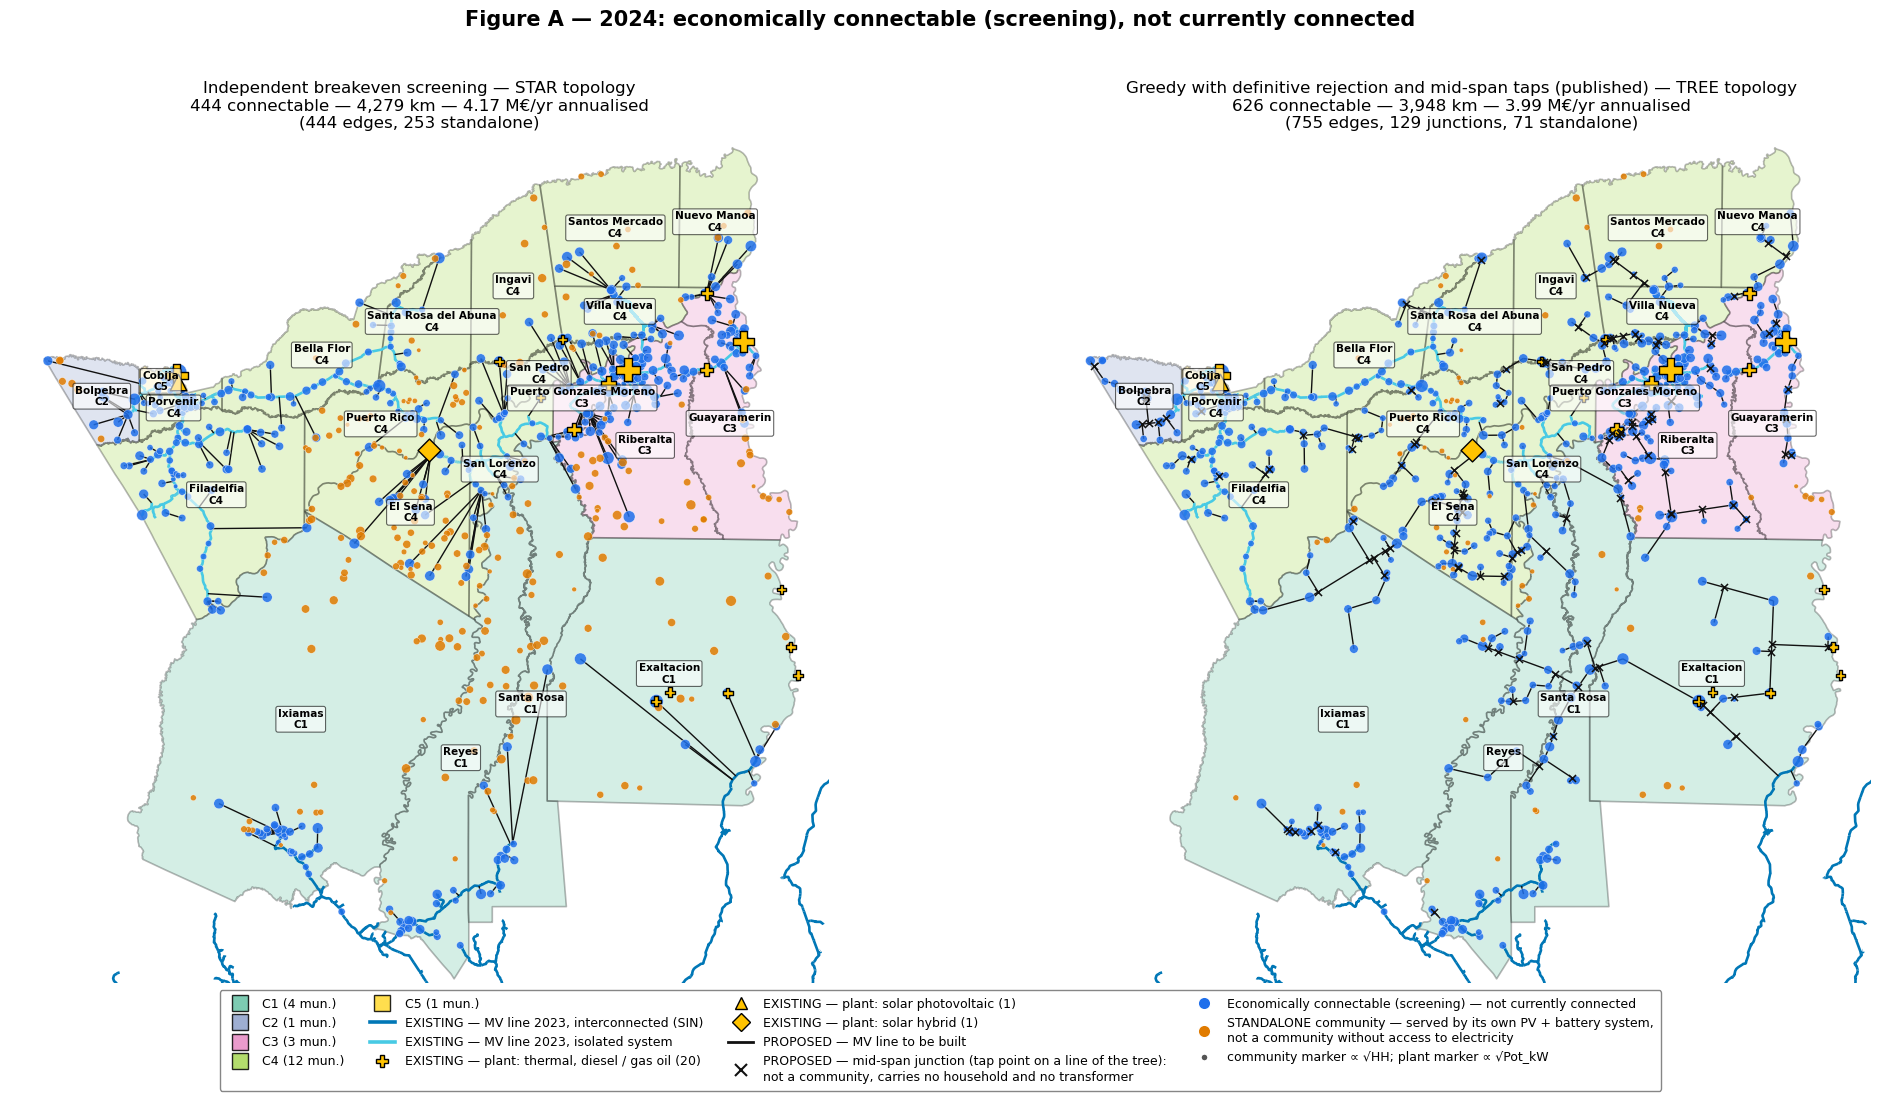

Figure A — 2024
  independent breakeven : 444 connectable, 4,279.43 km star, 4,170,409 EUR/yr
  published (taps)      : 626 connectable, 3,947.91 km tree, 129 junctions, 3,991,648 EUR/yr


In [67]:
# --- Figure A: 2024, independent breakeven (star) vs published greedy with taps (tree) -----
# Left panel unchanged: every connectable community runs its own spur to the network.
# Right panel: the published tree, whose junction nodes are drawn as crosses.
_y = "2024"
_ann_star = float(summary_breakeven[_y].set_index("Cluster").loc["TOTAL", "extension_capex_star_annualise_EUR"])
_ann_tree = float(published_summaries[_y].set_index("Cluster").loc["TOTAL", "extension_capex_annualise_EUR"])

fig_a, axes = plt.subplots(1, 2, figsize=(21, 11))
for _panel, (ax, (title, conn, segs, km, ann, jxy)) in enumerate(zip(axes, [
    ("Independent breakeven screening — STAR topology", conn_breakeven[_y],
     star_segments(conn_breakeven[_y]), star_km[_y], _ann_star, {}),
    ("Greedy with definitive rejection and mid-span taps (published) — TREE topology",
     conn_greedy[_y], [edge_segment(e, tree_geom[_y]) for e in tree_greedy[_y]],
     km_greedy[_y], _ann_tree, junction_xy[_y]),
])):
    draw_base(ax)
    ax.add_collection(LineCollection(segs, colors=C_EDGE, linewidths=1.0, zorder=2))
    draw_points(ax, conn, hh_by_year[_y])
    draw_junctions(ax, jxy)
    _jtxt = f", {len(jxy)} junctions" if jxy else ""
    ax.set_title(f"{title}\n{int(conn.sum())} connectable — {km:,.0f} km — "
                 f"{ann / 1e6:.2f} M€/yr annualised\n"
                 f"({len(segs)} edges{_jtxt}, {int((~conn).sum())} standalone)", fontsize=12)

fig_a.legend(handles=legend_handles([
    Line2D([], [], color=C_EDGE, lw=2.0, label="PROPOSED — MV line to be built"),
    Line2D([], [], marker="x", ls="", ms=8, mec=C_JUNCTION, mew=1.5, label=LEGEND_JUNCTION)]),
    loc="lower center", ncol=4, fontsize=9, frameon=True, edgecolor="gray",
    facecolor="white", framealpha=0.95, borderpad=0.6)
plt.tight_layout()
plt.subplots_adjust(top=0.87, bottom=0.10)
plt.suptitle(f"Figure A — {_y}: economically connectable (screening), not currently connected",
             fontweight="bold", fontsize=15, y=0.985)
plt.show()

print(f"Figure A — {_y}")
print(f"  independent breakeven : {int(conn_breakeven[_y].sum())} connectable, "
      f"{star_km[_y]:,.2f} km star, {_ann_star:,.0f} EUR/yr")
print(f"  published (taps)      : {int(conn_greedy[_y].sum())} connectable, "
      f"{km_greedy[_y]:,.2f} km tree, {len(junction_xy[_y])} junctions, {_ann_tree:,.0f} EUR/yr")

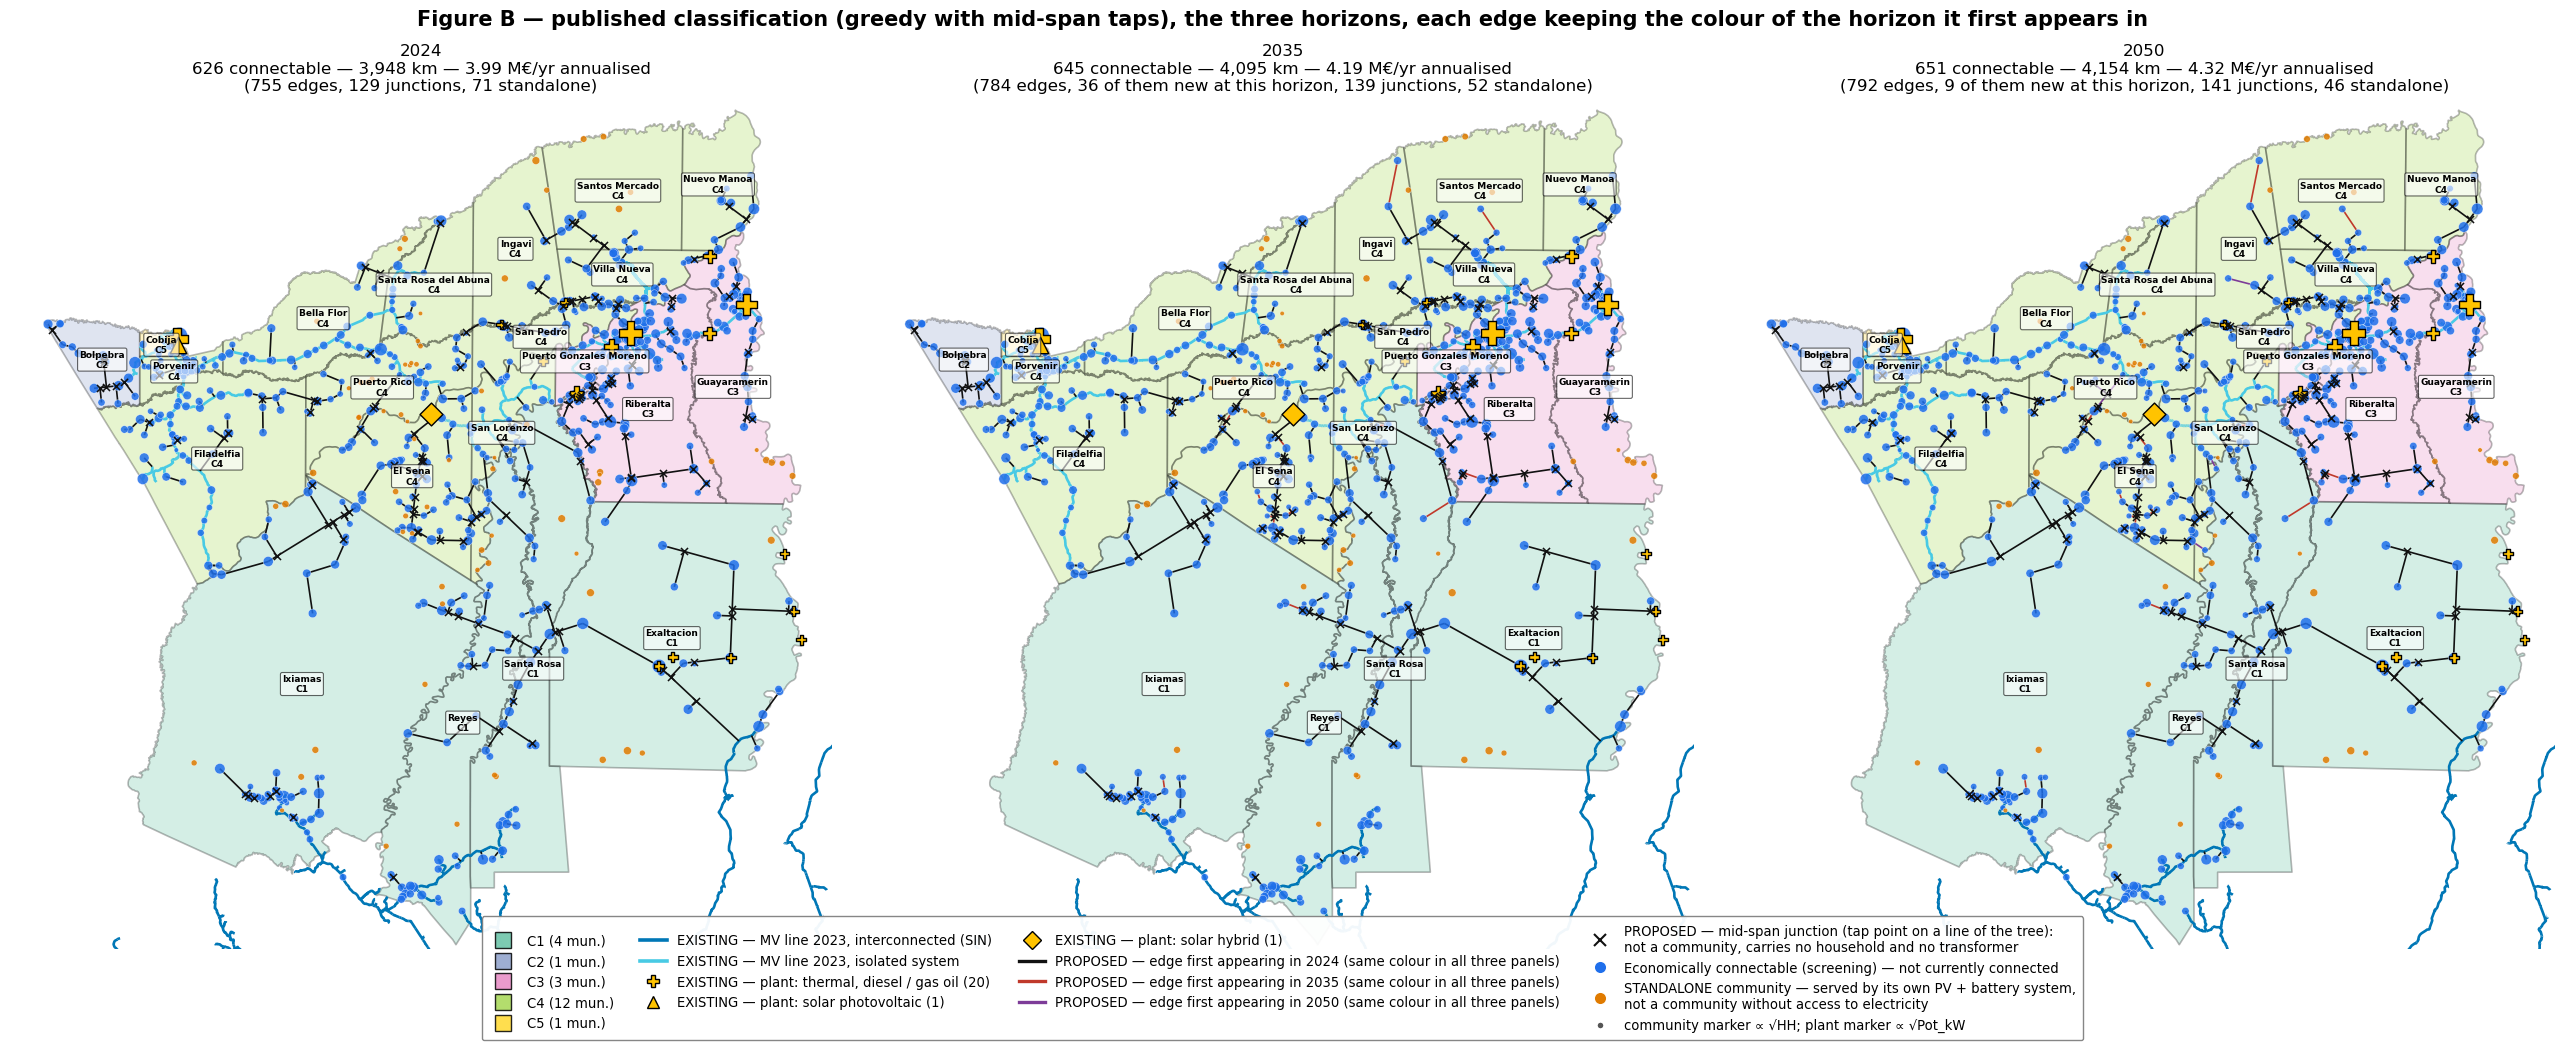

edges by horizon of first appearance (geometric identity):
  2024: 755 edges, still present in the 2050 tree: 747
  2035:  36 edges, still present in the 2050 tree:  36
  2050:   9 edges, still present in the 2050 tree:   9


In [68]:
# --- Figure B: the three horizons, edges coloured by the horizon they first appear in ------
# The published trees are built independently per horizon, so their edge sets are not nested. An
# edge keeps ONE colour across all three panels: that of the earliest horizon containing it.
# A 2024 edge therefore stays black in the 2035 and 2050 panels.
# Identity is GEOMETRIC (edge_geo_key), not by endpoint ids: junctions are numbered per run, so
# ("T", 7) of 2024 is not ("T", 7) of 2035, while the physical line is the same line.
edge_first_year, edge_segs = {}, {}
for _y in EXT_YEARS:
    for e in tree_greedy[_y]:
        _seg = edge_segment(e, tree_geom[_y])
        _k = edge_geo_key(_seg)
        edge_first_year.setdefault(_k, _y)
        edge_segs.setdefault((_y, _k), _seg)

fig_b, axes = plt.subplots(1, 3, figsize=(26, 10.5))
for ax, _y in zip(axes, EXT_YEARS):
    draw_base(ax, label_fs=6.5)
    _keys = [edge_geo_key(edge_segment(e, tree_geom[_y])) for e in tree_greedy[_y]]
    for _src in EXT_YEARS[:EXT_YEARS.index(_y) + 1]:
        _sub = [edge_segs[(_y, _k)] for _k in _keys if edge_first_year[_k] == _src]
        if _sub:
            ax.add_collection(LineCollection(_sub, colors=C_BY_YEAR[_src], linewidths=1.2,
                                             zorder=2))
    draw_points(ax, conn_greedy[_y], hh_by_year[_y])
    draw_junctions(ax, junction_xy[_y])
    _ann = float(published_summaries[_y].set_index("Cluster").loc["TOTAL", "extension_capex_annualise_EUR"])
    _new = sum(1 for _k in _keys if edge_first_year[_k] == _y)
    _new_txt = "" if _y == EXT_YEARS[0] else f", {_new} of them new at this horizon"
    ax.set_title(f"{_y}\n{int(conn_greedy[_y].sum())} connectable — {km_greedy[_y]:,.0f} km — "
                 f"{_ann / 1e6:.2f} M€/yr annualised\n"
                 f"({len(tree_greedy[_y])} edges{_new_txt}, {len(junction_xy[_y])} junctions, "
                 f"{int((~conn_greedy[_y]).sum())} standalone)", fontsize=12)

fig_b.legend(handles=legend_handles(
    [Line2D([], [], color=C_BY_YEAR[y], lw=2.4,
            label=f"PROPOSED — edge first appearing in {y} (same colour in all three panels)")
     for y in EXT_YEARS]
    + [Line2D([], [], marker="x", ls="", ms=8, mec=C_JUNCTION, mew=1.5, label=LEGEND_JUNCTION)]),
    loc="lower center", ncol=4, fontsize=9.5, frameon=True, edgecolor="gray",
    facecolor="white", framealpha=0.95, borderpad=0.6)
plt.tight_layout()
plt.subplots_adjust(top=0.90, bottom=0.09)
plt.suptitle("Figure B — published classification (greedy with mid-span taps), the three "
             "horizons, each edge keeping the colour of the horizon it first appears in",
             fontweight="bold", fontsize=15, y=0.985)
plt.show()

_last_keys = {edge_geo_key(edge_segment(e, tree_geom[EXT_YEARS[-1]]))
              for e in tree_greedy[EXT_YEARS[-1]]}
print("edges by horizon of first appearance (geometric identity):")
for _y in EXT_YEARS:
    _e = [_k for _k in edge_first_year if edge_first_year[_k] == _y]
    print(f"  {_y}: {len(_e):>3} edges, still present in the {EXT_YEARS[-1]} tree: "
          f"{sum(1 for _k in _e if _k in _last_keys):>3}")

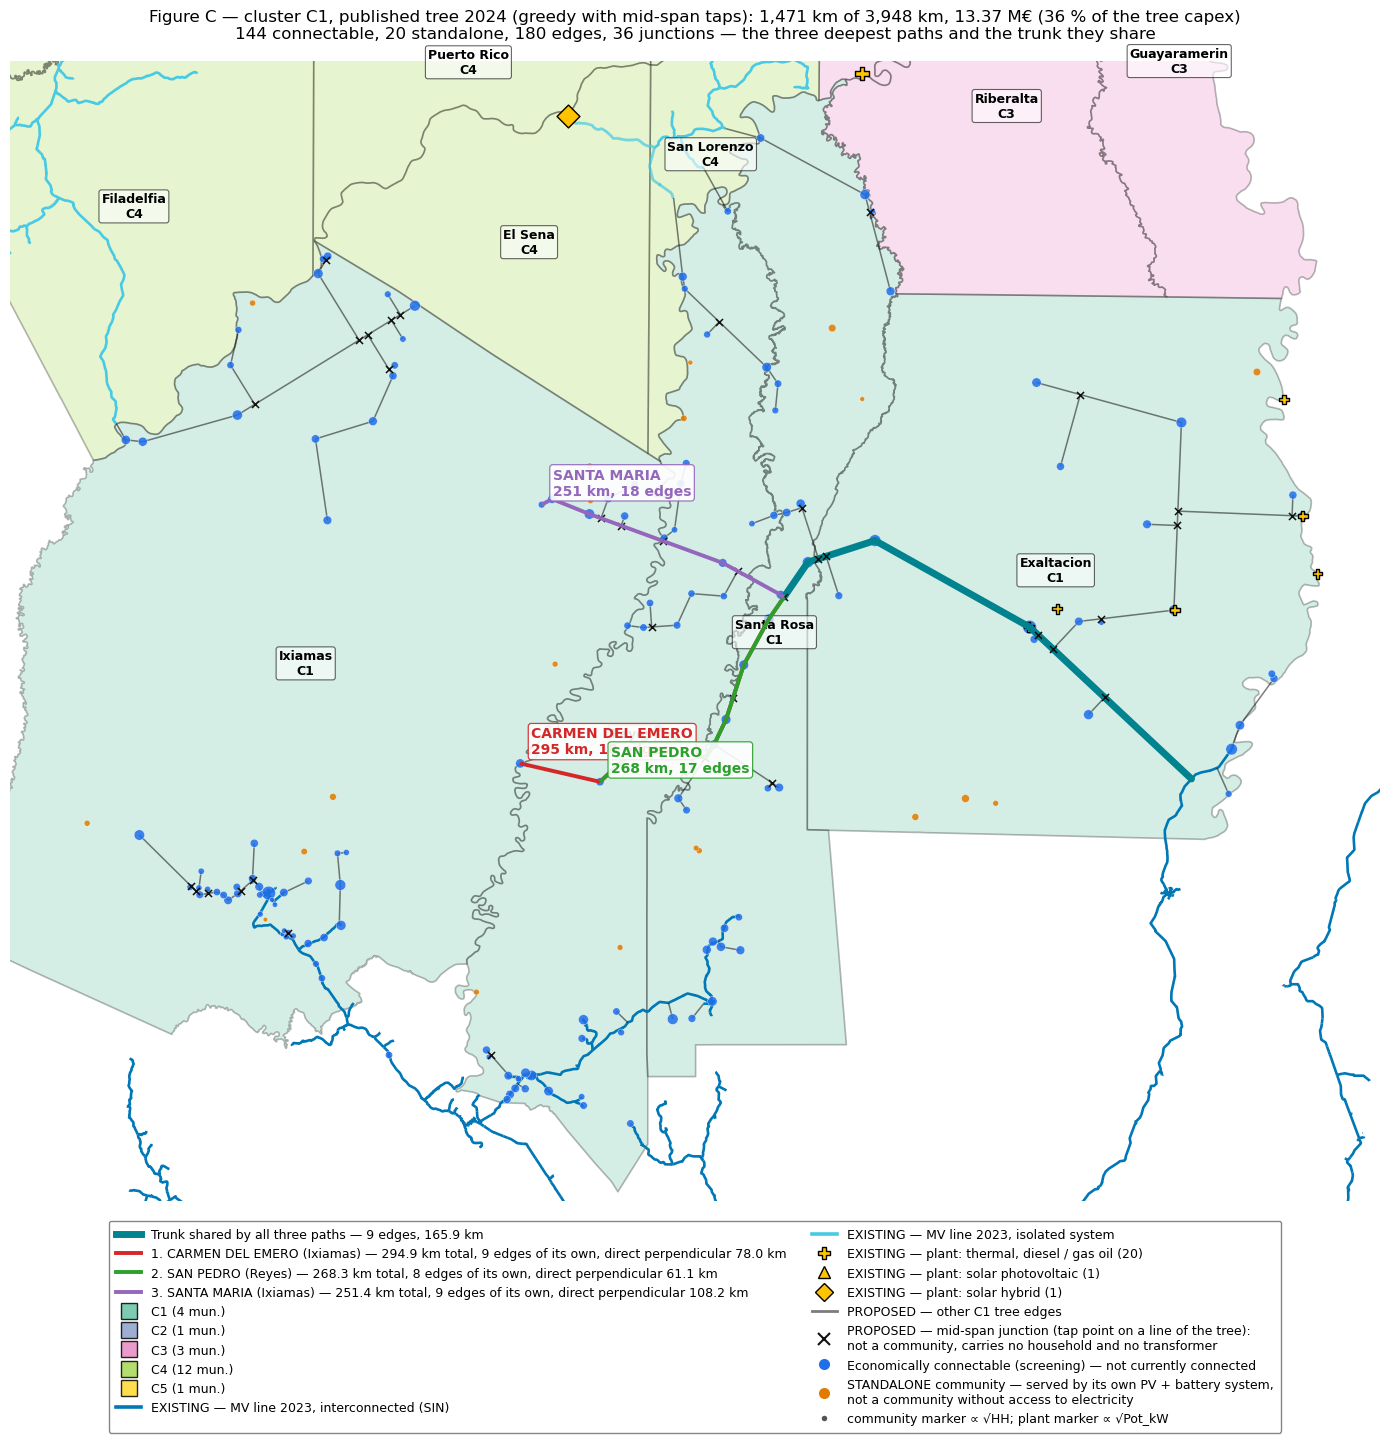

C1, published tree 2024 — three deepest paths to the network
  shared trunk: 9 edges, 165.85 km carried by all three
  junctions inside C1: 36
  1. CARMEN DEL EMERO          294.86 km over 18 edges,  9 of its own, direct perpendicular  78.03 km
  2. SAN PEDRO                 268.34 km over 17 edges,  8 of its own, direct perpendicular  61.14 km
  3. SANTA MARIA               251.45 km over 18 edges,  9 of its own, direct perpendicular 108.16 km


In [69]:
# --- Figure C: C1, the three deepest paths, and the trunk they share -----------------------
# This is the figure that shows the method: three communities far from the network do not each
# pay their own spur, they pay the branch beyond a shared trunk. The trunk common to all three
# paths is drawn in its own colour, and only the diverging segments carry the per-community
# colour, so the sharing is directly readable. A path may now run through junctions: those are
# tap points on a line already in the tree, and they carry no load of their own.
_y = "2024"
_c1 = (CL_ARR == "C1")
_par = tree_parents(tree_greedy[_y])
_edges_c1 = {e: w for e, w in tree_greedy[_y].items() if tree_geom[_y][e][2] == "C1"}

_paths = {n: path_edges_to_root(n, _par) for n in _par if is_community(n) and _c1[n]}
_tops = sorted(_paths, key=lambda n: -_paths[n][1])[:3]
_trunk = set.intersection(*(set(_paths[n][0]) for n in _tops))
_trunk_km = sum(tree_greedy[_y][e] for e in _trunk)

fig_c, ax = plt.subplots(figsize=(14, 14))
draw_base(ax, sub=_c1, label_fs=9)
ax.add_collection(LineCollection([edge_segment(e, tree_geom[_y]) for e in _edges_c1],
                                 colors=C_EDGE, linewidths=1.1, alpha=0.55, zorder=2))
draw_points(ax, conn_greedy[_y], hh_by_year[_y], sub=_c1)
_n_junc_c1 = draw_junctions(ax, junction_xy[_y], sub_cluster="C1", geom=tree_geom[_y])

# Shared trunk first, then only what each path adds beyond it.
ax.add_collection(LineCollection([edge_segment(e, tree_geom[_y]) for e in _trunk],
                                 colors=C_TRUNK, linewidths=5.0, zorder=4, capstyle="round"))
_handles = [Line2D([], [], color=C_TRUNK, lw=5.0,
                   label=f"Trunk shared by all three paths — {len(_trunk)} edges, {_trunk_km:,.1f} km")]
for _rank, (_n, _col) in enumerate(zip(_tops, C_PATHS), 1):
    _edges, _len = _paths[_n]
    _own = [e for e in _edges if e not in _trunk]
    ax.add_collection(LineCollection([edge_segment(e, tree_geom[_y]) for e in _own],
                                     colors=_col, linewidths=2.8, zorder=5))
    ax.annotate(f"{task1_geo['Comunidad'].iloc[_n]}\n{_len:,.0f} km, {len(_edges)} edges",
                (XY[_n, 0], XY[_n, 1]), xytext=(8, 7), textcoords="offset points",
                fontsize=10, weight="bold", color=_col, zorder=6,
                bbox=dict(boxstyle="round,pad=0.22", fc="white", ec=_col, linewidth=0.9, alpha=0.9))
    _handles.append(Line2D([], [], color=_col, lw=2.8, label=(
        f"{_rank}. {task1_geo['Comunidad'].iloc[_n]} "
        f"({task1_geo['Municipio_std'].iloc[_n].replace('_', ' ')}) — {_len:,.1f} km total, "
        f"{len(_own)} edges of its own, direct perpendicular {D_GRID[_n]:,.1f} km")))

_cs = published_summaries[_y].set_index("Cluster")
ax.set_title(
    f"Figure C — cluster C1, published tree {_y} (greedy with mid-span taps): "
    f"{km_greedy_cluster[_y]['C1']:,.0f} km of {km_greedy[_y]:,.0f} km, "
    f"{_cs.loc['C1', 'extension_capex_EUR'] / 1e6:.2f} M€ "
    f"({100 * _cs.loc['C1', 'extension_capex_EUR'] / _cs.loc['TOTAL', 'extension_capex_EUR']:.0f} % of the tree capex)\n"
    f"{int(conn_greedy[_y][_c1].sum())} connectable, {int((~conn_greedy[_y][_c1]).sum())} standalone, "
    f"{len(_edges_c1)} edges, {_n_junc_c1} junctions — the three deepest paths and the trunk they share",
    fontsize=12, pad=16)
fig_c.legend(handles=_handles + legend_handles([
    Line2D([], [], color=C_EDGE, lw=2.0, alpha=0.55, label="PROPOSED — other C1 tree edges"),
    Line2D([], [], marker="x", ls="", ms=8, mec=C_JUNCTION, mew=1.5, label=LEGEND_JUNCTION)]),
    loc="lower center", ncol=2, fontsize=9, frameon=True, edgecolor="gray",
    facecolor="white", framealpha=0.95, borderpad=0.6)
plt.tight_layout()
plt.subplots_adjust(bottom=0.16)
plt.show()

print(f"C1, published tree {_y} — three deepest paths to the network")
print(f"  shared trunk: {len(_trunk)} edges, {_trunk_km:,.2f} km carried by all three")
print(f"  junctions inside C1: {_n_junc_c1}")
for _rank, _n in enumerate(_tops, 1):
    _edges, _len = _paths[_n]
    print(f"  {_rank}. {task1_geo['Comunidad'].iloc[_n]:<24} {_len:>7,.2f} km over {len(_edges):>2} edges, "
          f"{len([e for e in _edges if e not in _trunk]):>2} of its own, "
          f"direct perpendicular {D_GRID[_n]:>6,.2f} km")

In [70]:
# --- Figure export, 300 dpi, versioned alongside the CSVs ----------------------------------
os.makedirs(FIG_DIR, exist_ok=True)
for _name, _fig in [("figure_A_2024_star_vs_greedy", fig_a),
                    ("figure_B_horizons_greedy", fig_b),
                    ("figure_C_C1_shared_trunk", fig_c)]:
    _path = os.path.join(FIG_DIR, f"{_name}.png")
    _fig.savefig(_path, dpi=300, bbox_inches="tight", facecolor="white")
    print(f"-> {_path}  ({os.path.getsize(_path) / 1e6:.1f} MB)")

-> output\figures\figure_A_2024_star_vs_greedy.png  (3.0 MB)
-> output\figures\figure_B_horizons_greedy.png  (2.8 MB)
-> output\figures\figure_C_C1_shared_trunk.png  (1.7 MB)


## 7. Control

The published numbers, re-read from the files on disk, checked against the expected constants.

In [71]:
# Control values of the published run — greedy with definitive rejection AND mid-span taps.
# A change here means the published CSVs moved. The node-only greedy and the independent
# breakeven are controlled beside them, on their own suffixed columns.
N_CONNECTABLE_EXPECTED = {"2024": 626, "2035": 645, "2050": 651}
N_DISPERSED_EXPECTED = {"2024": 71, "2035": 52, "2050": 46}
KM_TREE_EXPECTED = {"2024": 3_947.91, "2035": 4_095.38, "2050": 4_153.63}
CAPEX_EXPECTED_EUR = {"2024": 37_628_923, "2035": 39_535_168, "2050": 40_679_823}
CAPEX_ANNUALISE_EXPECTED_EUR = {"2024": 3_991_648, "2035": 4_193_861, "2050": 4_315_285}
N_JONCTIONS_EXPECTED = {"2024": 129, "2035": 139, "2050": 141}
N_NODE_ONLY_EXPECTED = {"2024": 614, "2035": 632, "2050": 640}      # _glouton_noeud_seul
N_BREAKEVEN_EXPECTED = {"2024": 444, "2035": 473, "2050": 491}      # _breakeven_independant

_conn_from_csv = {}
for year in EXT_YEARS:
    _tot = pd.read_csv(os.path.join(OUT, year, "cluster_summary.csv")).set_index("Cluster").loc["TOTAL"]
    _n, _capex = int(_tot["N_connectable"]), float(_tot["extension_capex_EUR"])
    assert _n == N_CONNECTABLE_EXPECTED[year], \
        f"{year}: N_connectable = {_n}, expected {N_CONNECTABLE_EXPECTED[year]}"
    assert int(_tot["N_dispersed"]) == N_DISPERSED_EXPECTED[year], \
        f"{year}: N_dispersed = {int(_tot['N_dispersed'])}, expected {N_DISPERSED_EXPECTED[year]}"
    assert abs(float(_tot["km_MT_arbre"]) - KM_TREE_EXPECTED[year]) <= 0.01, \
        f"{year}: tree = {_tot['km_MT_arbre']:,.2f} km, expected {KM_TREE_EXPECTED[year]:,.2f} km"
    assert abs(_capex - CAPEX_EXPECTED_EUR[year]) <= 1.0, \
        f"{year}: capex = {_capex:,.0f} EUR, expected {CAPEX_EXPECTED_EUR[year]:,} EUR"
    assert abs(float(_tot["extension_capex_annualise_EUR"])
               - CAPEX_ANNUALISE_EXPECTED_EUR[year]) <= 1.0, \
        f"{year}: annualised capex = {_tot['extension_capex_annualise_EUR']:,.0f} EUR, " \
        f"expected {CAPEX_ANNUALISE_EXPECTED_EUR[year]:,} EUR"
    assert int(_tot["N_jonctions"]) == N_JONCTIONS_EXPECTED[year], \
        f"{year}: {int(_tot['N_jonctions'])} junctions, expected {N_JONCTIONS_EXPECTED[year]}"
    # The transformer post is one per CONNECTED COMMUNITY. The tree has N_connectable +
    # N_jonctions edges, and pricing a transformer per edge would overstate the post by the
    # junction count: a junction is a tap on a line, not a served community.
    assert abs(float(_tot["extension_capex_transformateur_EUR"]) - _n * TRAFO_EUR) <= 1.0, \
        f"{year}: transformer post != N_connectable x TRAFO_EUR"
    assert float(_tot["extension_capex_transformateur_EUR"]) \
        != (_n + int(_tot["N_jonctions"])) * TRAFO_EUR, \
        f"{year}: transformer post priced on the edge count"
    assert int(_tot["N_connectable" + SUFFIX_NODE]) == N_NODE_ONLY_EXPECTED[year], \
        f"{year}: node-only greedy N_connectable != {N_NODE_ONLY_EXPECTED[year]}"
    assert int(_tot["N_connectable" + SUFFIX_OLD]) == N_BREAKEVEN_EXPECTED[year], \
        f"{year}: independent-breakeven N_connectable != {N_BREAKEVEN_EXPECTED[year]}"

    _det = pd.read_csv(os.path.join(OUT, year, "community_detail.csv"))
    assert int((~_det["dispersed"]).sum()) == N_CONNECTABLE_EXPECTED[year], \
        f"{year}: community_detail disagrees with cluster_summary on N_connectable"
    _conn_from_csv[year] = ~_det["dispersed"].to_numpy()
    print(f"{year}  N_connectable {_n} == {N_CONNECTABLE_EXPECTED[year]}   |   "
          f"N_dispersed {int(_tot['N_dispersed'])}   |   "
          f"capex {_capex:>12,.0f} == {CAPEX_EXPECTED_EUR[year]:>12,} EUR   |   "
          f"tree {_tot['km_MT_arbre']:>8,.2f} km   |   {int(_tot['N_jonctions']):>3} junctions   |   "
          f"annualised {_tot['extension_capex_annualise_EUR'] / 1e6:.2f} M€/yr")

# Nesting, re-read from the CSVs rather than from memory: a community connectable at one
# horizon must still be connectable at the next.
for _a, _b in zip(EXT_YEARS, EXT_YEARS[1:]):
    _lost = int((_conn_from_csv[_a] & ~_conn_from_csv[_b]).sum())
    assert _lost == 0, f"nesting broken between {_a} and {_b}: {_lost} community dropped out"
print(f"nesting {' - '.join(EXT_YEARS)} holds in the written CSVs -> OK")

# The two annualisation conventions, side by side. The CSVs carry CRF_MV alone; the
# classification that decided connectable vs standalone annualised at CRF_MV + OM_RATE. The gap
# is the O&M the published annualised capex does not show.
print()
print(f"annualisation: published CRF_MV = {CRF_MV:.8f}   vs   classification "
      f"CRF_MV + OM_RATE = {CRF_MV + OM_RATE:.8f}")
_rows = []
for year in EXT_YEARS:
    _cap = capex_posts(km_greedy[year], int(conn_greedy[year].sum()),
                       float(hh_by_year[year][conn_greedy[year]].sum()))
    _pub = float(pd.read_csv(os.path.join(OUT, year, "cluster_summary.csv"))
                 .set_index("Cluster").loc["TOTAL", "extension_capex_annualise_EUR"])
    assert abs(_cap["total_annualise_EUR"] - _pub) <= 1.0, f"{year}: annualised capex moved"
    _rows.append({
        "annee": year,
        "capex_EUR": round(_cap["total_EUR"], 0),
        "annualise_publie_EUR": round(_cap["total_annualise_EUR"], 0),
        "annualise_avec_om_EUR": round(_cap["total_annualise_avec_om_EUR"], 0),
        "ecart_EUR": round(_cap["total_annualise_avec_om_EUR"] - _cap["total_annualise_EUR"], 0),
        "ecart_%": round(100 * (_cap["total_annualise_avec_om_EUR"]
                                / _cap["total_annualise_EUR"] - 1), 2),
    })
print(pd.DataFrame(_rows).to_string(index=False))

_sd = pd.read_csv(os.path.join(OUT, "share_dispersion_final_BC.csv"))
assert int(_sd["N_connectable"].sum()) == N_CONNECTABLE_EXPECTED["2024"]
print()
print("output/share_dispersion_final_BC.csv")
print(_sd.to_string(index=False))
print()
print("--- demande_dispersee_GWh per cluster and horizon, published topology (the target)")
print(pd.DataFrame({_y: summary_greedy[_y].set_index("Cluster")["demande_dispersee_GWh"]
                    for _y in EXT_YEARS}).to_string())
print()
print("ALL CONTROLS PASSED — published files reproduce the expected values")

2024  N_connectable 626 == 626   |   N_dispersed 71   |   capex   37,628,923 ==   37,628,923 EUR   |   tree 3,947.91 km   |   129 junctions   |   annualised 3.99 M€/yr
2035  N_connectable 645 == 645   |   N_dispersed 52   |   capex   39,535,167 ==   39,535,168 EUR   |   tree 4,095.38 km   |   139 junctions   |   annualised 4.19 M€/yr
2050  N_connectable 651 == 651   |   N_dispersed 46   |   capex   40,679,822 ==   40,679,823 EUR   |   tree 4,153.63 km   |   141 junctions   |   annualised 4.32 M€/yr
nesting 2024 - 2035 - 2050 holds in the written CSVs -> OK

annualisation: published CRF_MV = 0.10607925   vs   classification CRF_MV + OM_RATE = 0.12607925
annee  capex_EUR  annualise_publie_EUR  annualise_avec_om_EUR  ecart_EUR  ecart_%
 2024 37628923.0             3991648.0              4744226.0   752578.0    18.85
 2035 39535168.0             4193861.0              4984564.0   790703.0    18.85
 2050 40679823.0             4315285.0              5128881.0   813596.0    18.85

output/sha

## 8. Diagnostic — households downstream of each tree edge

Read-only. Nothing is written and no published number moves. This section measures a quantity
the cost model deliberately ignores: **how many households sit downstream of each edge** of the
published greedy tree.

The tree is priced at a single `MV_EUR = 8 316 EUR/km` for every edge, whatever it carries — one
33 kV conductor size, from the trunk that feeds a whole branch down to the last spur serving a
single community. That is the assumption the limitations section has to bound, and the number
below is what bounds it: the most loaded edge of the tree is where a uniform conductor is least
defensible. **This figure enters no cost**; `extension_capex_EUR` and everything derived from it
are untouched.

Downstream is unambiguous because the tree is rooted at the existing MV network (`ROOT`): for the
edge `(child, parent)` it is the household sum of the subtree hanging off `child`.


In [72]:
# --- Diagnostic: households downstream of each edge of the published greedy tree ------------
# READ-ONLY. No file is written and no published value is recomputed. Bound for the conductor-
# reinforcement limitation only: the tree prices every edge at the same MV_EUR/km regardless of
# how many households it carries, and this cell says how far that is stretched.
# Figure C's trunk definition is reused verbatim (three deepest C1 paths, edges common to all
# three) and cross-checked against the figure itself when this cell runs after it.

_FIGC_TRUNK_2024 = set(_trunk) if "_trunk" in globals() else None


def edge_downstream_table(edges, geom, hh):
    """One row per tree edge: child, parent, km, households downstream of that edge.

    Rooted at ROOT, so the far side of an edge from the grid is well defined: for the edge
    (child, parent) the downstream load is the household sum of the subtree hanging off `child`.
    `hh` is the per-community household array of that horizon. A junction contributes 0: it is a
    tap point on a line, not a served community, so it adds nothing to the load it passes on.
    """
    par = tree_parents(edges)              # {node: (parent, km)}; asserts the edge set is a tree
    children = {}
    for _n, (_p, _) in par.items():
        children.setdefault(_p, []).append(_n)

    order, stack = [], [ROOT]               # root-first, so reversed() sums leaves before parents
    while stack:
        u = stack.pop()
        order.append(u)
        stack.extend(children.get(u, []))
    assert len(order) == len(par) + 1, "traversal did not reach every node of the tree"

    sub = {}
    for u in reversed(order):
        if u != ROOT:
            sub[u] = (float(hh[u]) if is_community(u) else 0.0) \
                + sum(sub[v] for v in children.get(u, []))

    rows = [{"child": n, "parent": p, "km": w, "downstream_hh": sub[n],
             "own_hh": float(hh[n]) if is_community(n) else 0.0,
             "n_children": len(children.get(n, [])),
             "cluster": geom[frozenset((n, p))][2], "edge": frozenset((n, p))}
            for n, (p, w) in par.items()]
    df = pd.DataFrame(rows)
    assert len(df) == len(edges), "one row per edge"
    # the load closes: every connected household hangs off exactly one root edge
    assert abs(df.loc[df["parent"] == ROOT, "downstream_hh"].sum()
               - df["own_hh"].sum()) < 1e-6, "downstream loads do not close on the tree total"
    return df


def _node_label(n):
    """Readable endpoint name; ROOT is the existing network and a junction is a tap point,
    neither of them a community."""
    if n == ROOT:
        return "GRID (existing MV network)"
    if not is_community(n):
        return f"JUNCTION {n[1]} (mid-span tap, no load)"
    return (f"{task1_geo['Comunidad'].iloc[n]} "
            f"[{task1_geo['Municipio_std'].iloc[n].replace('_', ' ')}, {CL_ARR[n]}]")


DOWNSTREAM_BY_YEAR, TRUNK_C1_BY_YEAR = {}, {}
_dist_rows, _top_rows, _trunk_rows = [], [], []

for year in EXT_YEARS:
    _edges = tree_greedy[year]
    _hh = hh_by_year[year]
    _df = edge_downstream_table(_edges, tree_geom[year], _hh)
    DOWNSTREAM_BY_YEAR[year] = _df
    _d = _df["downstream_hh"]

    _dist_rows.append({
        "annee": year,
        "n_aretes": len(_df),
        "menages_raccordes": round(float(_df["own_hh"].sum()), 0),
        "aval_min": round(float(_d.min()), 0),
        "aval_q25": round(float(_d.quantile(0.25)), 0),
        "aval_median": round(float(_d.median()), 0),
        "aval_moyen": round(float(_d.mean()), 1),
        "aval_q75": round(float(_d.quantile(0.75)), 0),
        "aval_q90": round(float(_d.quantile(0.90)), 0),
        "aval_max": round(float(_d.max()), 0),
        "aretes_terminales": int((_df["n_children"] == 0).sum()),
        "aretes_aval_sup_100": int((_d > 100).sum()),
        "aretes_aval_sup_500": int((_d > 500).sum()),
        "aretes_aval_sup_1000": int((_d > 1000).sum()),
        "km_arete_la_plus_chargee": round(float(_df.loc[_d.idxmax(), "km"]), 2),
        "ratio_max_sur_median": round(float(_d.max() / _d.median()), 1),
    })

    for _rank, (_, _r) in enumerate(_df.sort_values("downstream_hh", ascending=False)
                                    .head(10).iterrows(), 1):
        _top_rows.append({
            "annee": year, "rang": _rank,
            "menages_aval": round(_r["downstream_hh"], 0),
            "km_arete": round(_r["km"], 2),
            "cluster": _r["cluster"],
            "extremite_aval": _node_label(_r["child"]),
            "extremite_amont": _node_label(_r["parent"]),
        })

    # --- C1 shared trunk, Figure C's definition, applied at each horizon
    _par_y = tree_parents(_edges)
    _paths_y = {n: path_edges_to_root(n, _par_y)
                for n in _par_y if is_community(n) and CL_ARR[n] == "C1"}
    _tops_y = sorted(_paths_y, key=lambda n: -_paths_y[n][1])[:3]
    _trunk_y = set.intersection(*(set(_paths_y[n][0]) for n in _tops_y))
    TRUNK_C1_BY_YEAR[year] = _trunk_y
    if year == "2024" and _FIGC_TRUNK_2024 is not None:
        assert _trunk_y == _FIGC_TRUNK_2024, "trunk does not reproduce Figure C's trunk"

    _t = _df[_df["edge"].isin(_trunk_y)]
    assert len(_t) == len(_trunk_y), "trunk edges not all found in the edge table"
    _root_most = _t.loc[_t["downstream_hh"].idxmax()]
    _c1_conn = float(_hh[(CL_ARR == "C1") & conn_greedy[year]].sum())
    _trunk_rows.append({
        "annee": year,
        "aretes_tronc": len(_t),
        "km_tronc": round(float(_t["km"].sum()), 2),
        "aval_arete_racine": round(float(_root_most["downstream_hh"]), 0),
        "km_arete_racine": round(float(_root_most["km"]), 2),
        "aval_arete_extremite": round(float(_t["downstream_hh"].min()), 0),
        "menages_C1_raccordes": round(_c1_conn, 0),
        "part_C1_sur_arete_racine_pct": round(100 * float(_root_most["downstream_hh"]) / _c1_conn, 1),
        "communautes_les_plus_profondes": " | ".join(
            task1_geo["Comunidad"].iloc[n] for n in _tops_y),
    })

diag_distribution = pd.DataFrame(_dist_rows)
diag_top10 = pd.DataFrame(_top_rows)
diag_trunk_c1 = pd.DataFrame(_trunk_rows)

print("DOWNSTREAM LOAD PER EDGE - published tree (greedy with mid-span taps), read-only")
print("this figure enters no cost; extension_capex_EUR is untouched")
print()
print("--- distribution of the downstream household load, per edge")
print(diag_distribution.to_string(index=False))
print()
print("--- the ten most loaded edges of each horizon")
for _y in EXT_YEARS:
    print(f"  {_y}")
    print(diag_top10[diag_top10["annee"] == _y][
        ["rang", "menages_aval", "km_arete", "cluster",
         "extremite_aval", "extremite_amont"]].to_string(index=False))
print()
print("--- C1 shared trunk (Figure C definition: edges common to the three deepest C1 paths)")
print(diag_trunk_c1.to_string(index=False))
print()
print("nothing written")

DOWNSTREAM LOAD PER EDGE - published tree (greedy with mid-span taps), read-only
this figure enters no cost; extension_capex_EUR is untouched

--- distribution of the downstream household load, per edge
annee  n_aretes  menages_raccordes  aval_min  aval_q25  aval_median  aval_moyen  aval_q75  aval_q90  aval_max  aretes_terminales  aretes_aval_sup_100  aretes_aval_sup_500  aretes_aval_sup_1000  km_arete_la_plus_chargee  ratio_max_sur_median
 2024       755            20012.0       1.0      15.0         35.0       125.8     105.0     331.0    1941.0                424                  198                   45                    18                     38.59                  54.9
 2035       784            24474.0       1.0      18.0         42.0       152.2     124.0     403.0    2302.0                434                  232                   61                    29                     38.59                  54.7
 2050       792            29097.0       1.0      22.0         49.0       

## 9. Diagnostic — what the node-only restriction costs

Read-only. Nothing is written and no published value moves. The published classification allows
mid-span taps (section 3); `greedy_connect` without them is computed in section 4 alongside, and
this section is the difference between the two, read off variables that already exist.

The restriction it measures is the one lifted in section 3: without taps, a community can only
attach to a node. On the node-only 2024 tree, 43 of its 83 standalone communities had a tree edge
passing closer than any attachable node, and 32 of them projected strictly inside a
community–community edge.

> `conn_noeud_seul`, `tree_noeud_seul`, `km_noeud_seul` are the node-only run;
> `conn_greedy`, `tree_greedy`, `tree_geom`, `km_greedy`, `junction_xy` are the published one.

In [73]:
# --- Diagnostic: what the node-only restriction costs ---------------------------------------
# READ-ONLY. Nothing is written. Both classifications were already computed in section 4; this
# cell only reads them, so no algorithm runs twice.

TAP_ROWS = []
for year in EXT_YEARS:
    _hh = hh_by_year[year]
    _conn_t, _conn_n = conn_greedy[year], conn_noeud_seul[year]
    _cap_t = capex_posts(km_greedy[year], int(_conn_t.sum()), float(_hh[_conn_t].sum()))
    _cap_n = capex_posts(km_noeud_seul[year], int(_conn_n.sum()), float(_hh[_conn_n].sum()))
    _taps = tap_out[year]["tap_edge_km"]
    _kind = tap_out[year]["attach_kind"]
    TAP_ROWS.append({
        "annee": year,
        "N_conn_publie": int(_conn_t.sum()), "N_conn_noeud_seul": int(_conn_n.sum()),
        "N_disp_publie": int((~_conn_t).sum()), "N_disp_noeud_seul": int((~_conn_n).sum()),
        "km_publie": round(km_greedy[year], 2), "km_noeud_seul": round(km_noeud_seul[year], 2),
        "capex_publie_EUR": round(_cap_t["total_EUR"], 0),
        "capex_noeud_seul_EUR": round(_cap_n["total_EUR"], 0),
        "capex_ann_publie_EUR": round(_cap_t["total_annualise_EUR"], 0),
        "capex_ann_noeud_seul_EUR": round(_cap_n["total_annualise_EUR"], 0),
        "n_jonctions": len(junction_xy[year]),
        "km_piquage_moyen": round(float(_taps.mean()), 4) if len(_taps) else np.nan,
        "km_piquage_median": round(float(np.median(_taps)), 4) if len(_taps) else np.nan,
        "km_piquage_min": round(float(_taps.min()), 4) if len(_taps) else np.nan,
        "km_piquage_max": round(float(_taps.max()), 4) if len(_taps) else np.nan,
        "attache_reseau": int((_kind[_conn_t] == "root").sum()),
        "attache_noeud": int((_kind[_conn_t] == "node").sum()),
        "attache_piquage": int((_kind[_conn_t] == "tap").sum()),
    })
tap_summary = pd.DataFrame(TAP_ROWS)

print("PUBLISHED (mid-span taps) vs NODE-ONLY GREEDY - read-only diagnostic")
print("nothing written; both classifications come from section 4")
print()
print("--- 1. classification, tree and capex")
print(tap_summary[["annee", "N_conn_publie", "N_conn_noeud_seul", "N_disp_publie",
                   "N_disp_noeud_seul", "km_publie", "km_noeud_seul"]].to_string(index=False))
print()
print(tap_summary[["annee", "capex_publie_EUR", "capex_noeud_seul_EUR",
                   "capex_ann_publie_EUR", "capex_ann_noeud_seul_EUR"]].to_string(index=False))
print()
for _, _r in tap_summary.iterrows():
    print(f"  {_r['annee']}: dN_connectable {_r['N_conn_publie'] - _r['N_conn_noeud_seul']:+d}   "
          f"dkm {_r['km_publie'] - _r['km_noeud_seul']:+,.2f} "
          f"({100 * (_r['km_publie'] / _r['km_noeud_seul'] - 1):+.2f} %)   "
          f"dcapex {_r['capex_publie_EUR'] - _r['capex_noeud_seul_EUR']:+,.0f} EUR "
          f"({100 * (_r['capex_publie_EUR'] / _r['capex_noeud_seul_EUR'] - 1):+.2f} %)   "
          f"dcapex annualise "
          f"{_r['capex_ann_publie_EUR'] - _r['capex_ann_noeud_seul_EUR']:+,.0f} EUR/an")

print()
print("--- 2. junctions, and how each connected community attaches")
print(tap_summary[["annee", "n_jonctions", "km_piquage_moyen", "km_piquage_median",
                   "km_piquage_min", "km_piquage_max", "attache_reseau", "attache_noeud",
                   "attache_piquage"]].to_string(index=False))

print()
print("--- 3. switches node-only -> published, per cluster")
_sw_rows = []
for year in EXT_YEARS:
    _conn_n, _conn_t = conn_noeud_seul[year], conn_greedy[year]
    _gain, _loss = (~_conn_n) & _conn_t, _conn_n & (~_conn_t)
    for cluster in list(CLUSTERS) + ["TOTAL"]:
        _m = np.ones(len(CL_ARR), dtype=bool) if cluster == "TOTAL" else (CL_ARR == cluster)
        _sw_rows.append({"annee": year, "cluster": cluster, "N_communautes": int(_m.sum()),
                         "dispersee_vers_connectable": int(_gain[_m].sum()),
                         "connectable_vers_dispersee": int(_loss[_m].sum()),
                         "N_conn_noeud_seul": int(_conn_n[_m].sum()),
                         "N_conn_publie": int(_conn_t[_m].sum())})
tap_switches = pd.DataFrame(_sw_rows)
print(tap_switches.to_string(index=False))

print()
print("--- 4. share_dispersion per cluster, aggregate_clusters definition")
print("    (households of the dispersed communities / households of the cluster; this is NOT the")
print("     energy ratio EnergyScope is fed in the access and projection scenarios)")
_sd_rows = []
for cluster in CLUSTERS:
    _m = CL_ARR == cluster
    _row = {"cluster": cluster}
    for year in EXT_YEARS:
        _hh, _den = hh_by_year[year], float(SCENARIOS[year][cluster])
        _row[f"{year}_publie"] = round(_hh[_m & (~conn_greedy[year])].sum() / _den, 4)
        _row[f"{year}_noeud_seul"] = round(_hh[_m & (~conn_noeud_seul[year])].sum() / _den, 4)
    _sd_rows.append(_row)
tap_share_dispersion = pd.DataFrame(_sd_rows)
print(tap_share_dispersion.to_string(index=False))

print()
print("--- 5. the communities still dispersed, and the edge nearest to them")
_nb_rows = []
for year in EXT_YEARS:
    _disp = np.where(~conn_greedy[year])[0]
    _keys = list(tree_greedy[year])
    _A = np.array([tree_geom[year][e][0] for e in _keys])
    _B = np.array([tree_geom[year][e][1] for e in _keys])
    _d_near, _cl_near = [], []
    for i in _disp:
        _d, _t = _dist_point_to_segments(XY[i], _A, _B)
        _a = int(np.argmin(_d))
        _d_near.append(float(_d[_a]))
        _cl_near.append(tree_geom[year][_keys[_a]][2])
    _d_near = np.array(_d_near)
    _other = np.array([_cl_near[k] != CL_ARR[i] for k, i in enumerate(_disp)])
    _nb_rows.append({
        "annee": year, "N_dispersee": len(_disp),
        "arete_proche_autre_cluster": int(_other.sum()),
        "d_min_km": round(float(_d_near.min()), 4),
        "d_q25_km": round(float(np.quantile(_d_near, 0.25)), 4),
        "d_mediane_km": round(float(np.median(_d_near)), 4),
        "d_q75_km": round(float(np.quantile(_d_near, 0.75)), 4),
        "d_max_km": round(float(_d_near.max()), 4),
        "moins_1km": int((_d_near < 1).sum()), "moins_2km": int((_d_near < 2).sum()),
        "moins_5km": int((_d_near < 5).sum()),
    })
tap_remaining = pd.DataFrame(_nb_rows)
print(tap_remaining.to_string(index=False))
print()
print("an edge carried by another cluster is unusable by construction: inter-cluster edges are")
print("forbidden in the published classification and in the node-only one alike")
print()
print("nothing written")

PUBLISHED (mid-span taps) vs NODE-ONLY GREEDY - read-only diagnostic
nothing written; both classifications come from section 4

--- 1. classification, tree and capex
annee  N_conn_publie  N_conn_noeud_seul  N_disp_publie  N_disp_noeud_seul  km_publie  km_noeud_seul
 2024            626                614             71                 83    3947.91        4125.63
 2035            645                632             52                 65    4095.38        4327.57
 2050            651                640             46                 57    4153.63        4396.38

annee  capex_publie_EUR  capex_noeud_seul_EUR  capex_ann_publie_EUR  capex_ann_noeud_seul_EUR
 2024        37628923.0            39054905.0             3991648.0                 4142915.0
 2035        39535168.0            41415700.0             4193861.0                 4393346.0
 2050        40679823.0            42653750.0             4315285.0                 4524678.0

  2024: dN_connectable +12   dkm -177.72 (-4.31 %)   dca

## 10. Diagnostic — sub-optimality of the published tree

Read-only. Nothing is written. The greedy is an ordering heuristic, not an optimiser: it accepts
the cheapest candidate at each step and never revisits an edge it has laid. This section puts a
number on that, so the point does not have to be made in passing: the **minimum spanning tree
over exactly the published connected set**, on the node-only allowed edges (community–root and
same-cluster community–community, `build_tree_mst`), and the gap to the published tree in km, in
per cent, and on the line post of the capex.

The MST is a lower bound on the node-only edge set, not a candidate topology: no incremental rule
reaches it, and it says nothing about **which** communities are worth connecting — the connected
set is taken as published and never re-decided here.

In [74]:
# --- Diagnostic: how far the published tree sits from the shortest tree on the same set -----
# READ-ONLY. Nothing is written and no published value moves.
# The greedy is an ordering heuristic, not an optimiser: it accepts the cheapest candidate at
# each step and never revisits an edge it has laid. The reference below is the node-only minimum
# spanning tree over EXACTLY the published connected set — the shortest tree the allowed node
# edges can form on that set (build_tree_mst, community-root and same-cluster community-community
# edges). The gap is the sub-optimality of the published tree, in km and in per cent, on the
# tree length and on the line post of the capex it drives.
# The MST is not a candidate topology: it is not reachable by an incremental rule, and it says
# nothing about which communities are worth connecting — the connected set is taken as published.
_rows = []
for year in EXT_YEARS:
    _idx = np.where(conn_greedy[year])[0]
    _mst = build_tree_mst(_idx, CL_ARR)
    _km_mst, _ = check_tree(_mst, conn_greedy[year], f"{year} MST on the published set")
    _km_no_tap = float(sum(greedy_tree_nodes_only(_idx, hh_by_year[year]).values()))
    _km_pub = km_greedy[year]
    assert _km_mst <= _km_no_tap + 1e-9, f"{year}: the MST is not the node-only shortest tree"
    _rows.append({
        "annee": year,
        "N_connectable_publie": int(conn_greedy[year].sum()),
        "km_arbre_publie": round(_km_pub, 2),
        "km_mst_meme_ensemble": round(_km_mst, 2),
        "km_glouton_sans_piquage_meme_ensemble": round(_km_no_tap, 2),
        "ecart_publie_vs_mst_km": round(_km_pub - _km_mst, 2),
        "ecart_publie_vs_mst_%": round(100 * (_km_pub / _km_mst - 1), 2),
        "ecart_sans_piquage_vs_mst_%": round(100 * (_km_no_tap / _km_mst - 1), 2),
        "poste_ligne_publie_EUR": round(_km_pub * MV_EUR, 0),
        "poste_ligne_mst_EUR": round(_km_mst * MV_EUR, 0),
        "ecart_poste_ligne_EUR": round((_km_pub - _km_mst) * MV_EUR, 0),
        "ecart_sur_capex_total_%": round(
            100 * (_km_pub - _km_mst) * MV_EUR
            / float(published_summaries[year].set_index("Cluster").loc["TOTAL",
                                                                       "extension_capex_EUR"]), 2),
    })
diag_mst = pd.DataFrame(_rows)

print("SUB-OPTIMALITY OF THE PUBLISHED TREE - read-only diagnostic, nothing written")
print("reference: node-only minimum spanning tree over the published connected set")
print()
print(diag_mst.to_string(index=False))
print()
for _, _r in diag_mst.iterrows():
    print(f"  {_r['annee']}: published {_r['km_arbre_publie']:>8,.2f} km vs MST "
          f"{_r['km_mst_meme_ensemble']:>8,.2f} km -> +{_r['ecart_publie_vs_mst_km']:,.2f} km "
          f"(+{_r['ecart_publie_vs_mst_%']:.2f} %), line post +{_r['ecart_poste_ligne_EUR']:,.0f} EUR, "
          f"{_r['ecart_sur_capex_total_%']:.2f} % of the published capex")
print()
print("nothing written")

SUB-OPTIMALITY OF THE PUBLISHED TREE - read-only diagnostic, nothing written
reference: node-only minimum spanning tree over the published connected set

annee  N_connectable_publie  km_arbre_publie  km_mst_meme_ensemble  km_glouton_sans_piquage_meme_ensemble  ecart_publie_vs_mst_km  ecart_publie_vs_mst_%  ecart_sans_piquage_vs_mst_%  poste_ligne_publie_EUR  poste_ligne_mst_EUR  ecart_poste_ligne_EUR  ecart_sur_capex_total_%
 2024                   626          3947.91               3669.17                                4270.06                  278.73                   7.60                        16.38              32830797.0           30512838.0              2317960.0                     6.16
 2035                   645          4095.38               3782.73                                4427.14                  312.66                   8.27                        17.04              34057199.0           31457151.0              2600048.0                     6.58
 2050                